# 1. Project Setup

Load in Packages and input data

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorly.decomposition import parafac
from tensorly import cp_to_tensor
import tensorly as tl
from tensorly import norm
import matplotlib.pyplot as plt
from statsmodels.tsa.api import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
tl.set_backend('pytorch')

from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts import TimeSeries
from darts.models.forecasting.sf_auto_ets import AutoETS
from darts.metrics import mse, rmse
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
from tlviz.visualisation import components_plot


In [2]:
noise_complaints_df=pd.read_csv('data/311_Service_Requests_Combined.csv')
noise_complaints_df_use=noise_complaints_df[['Created Date','Complaint Type','Community Board']]
noise_complaints_df_use['Year_Month'] = pd.to_datetime(noise_complaints_df_use['Created Date'],format='%m/%d/%Y %H:%M:%S %p').dt.to_period('M')
noise_complaints_grouped = noise_complaints_df_use.groupby(['Year_Month', 'Complaint Type', 'Community Board']).size().reset_index(name='count')

#create rows for all combinations of Year_Month, complaint_type, and community_board
all_year_months = noise_complaints_grouped['Year_Month'].unique()
all_complaint_types = noise_complaints_grouped['Complaint Type'].unique()
all_community_boards = noise_complaints_grouped['Community Board'].unique()
all_combinations = pd.MultiIndex.from_product([all_year_months, all_complaint_types, all_community_boards], names=['Year_Month', 'Complaint Type', 'Community Board']).to_frame(index=False)
noise_complaints_complete = pd.merge(all_combinations, noise_complaints_grouped, on=['Year_Month', 'Complaint Type', 'Community Board'], how='left').fillna(0)

#Check that there is no missing months between 2014  and 2024
all_months = pd.period_range(start='2014-01', end='2024-04', freq='M')
missing_months = set(all_months) - set(noise_complaints_complete['Year_Month'].unique())

#Convert Year_Month back to string for tensor decomposition
noise_complaints_complete['Year_Month'] = noise_complaints_complete['Year_Month'].astype(str)
noise_complaints_complete

/var/folders/k7/nwx94c9x67zdym9bg8_s7w_r0000gn/T/ipykernel_62167/2832353657.py:1: DtypeWarning: Columns (17,18,20,31) have mixed types. Specify dtype option on import or set low_memory=False.
  noise_complaints_df=pd.read_csv('data/311_Service_Requests_Combined.csv')
/var/folders/k7/nwx94c9x67zdym9bg8_s7w_r0000gn/T/ipykernel_62167/2832353657.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  noise_complaints_df_use['Year_Month'] = pd.to_datetime(noise_complaints_df_use['Created Date'],format='%m/%d/%Y %H:%M:%S %p').dt.to_period('M')


,Year_Month,Complaint Type,Community Board,count
0,2014-01,Collection Truck Noise,01 BROOKLYN,1.0
1,2014-01,Collection Truck Noise,01 STATEN ISLAND,2.0
2,2014-01,Collection Truck Noise,02 QUEENS,1.0
3,2014-01,Collection Truck Noise,06 BROOKLYN,1.0
4,2014-01,Collection Truck Noise,09 BROOKLYN,1.0
...,...,...,...,...
91471,2024-12,Noise - Vehicle,56 BROOKLYN,0.0
91472,2024-12,Noise - Vehicle,27 BRONX,0.0
91473,2024-12,Noise - Vehicle,80 QUEENS,0.0
91474,2024-12,Noise - Vehicle,84 QUEENS,0.0


Split the dataset into train and test

Training : 1/1/2014 - 12/31/2022 : 108 months

Test: 1/1/2023 - 12/31/2024 : 24 months

Infrastructure for CP decomp and rank selection via AIC

The rank value is equal to the number of components (hidden patterns) that are created for each respectice factor that are we tracking. 

The AIC is an error that balances the model's goodness of fit and the complexity.

How well does the model explain/fit the data via an MLE. What is the probability of observiing this data given the model?

In [3]:
#Train and Test Split
train_df = noise_complaints_complete[noise_complaints_complete['Year_Month'] <= '2022-12']
test_df = noise_complaints_complete[noise_complaints_complete['Year_Month'] >= '2023-01']

train_tensor = train_df.pivot_table(
    index='Year_Month', 
    columns=['Complaint Type', 'Community Board'], 
    values='count', 
    fill_value=0
).reindex(columns=pd.MultiIndex.from_product([all_complaint_types, all_community_boards], names=['Complaint Type', 'Community Board']), fill_value=0).values
train_tensor = train_tensor.reshape((train_tensor.shape[0], len(all_complaint_types), len(all_community_boards)))


ranks = np.arange(1, 11)

train_tensor=tl.tensor(train_tensor)

ranked_reconstructed_tensors=[]
AIC_List=[]

for r in ranks:
    weights,factors = parafac(train_tensor, rank=r, normalize_factors=True)
    
    reconstructed_tensor_r = cp_to_tensor((weights, factors))
    ranked_reconstructed_tensors.append((r,reconstructed_tensor_r))
    
    AIC_r = (2*norm(train_tensor - reconstructed_tensor_r)**2) + (2*r)
    
    AIC_List.append(AIC_r)


AIC Rank selection Viz

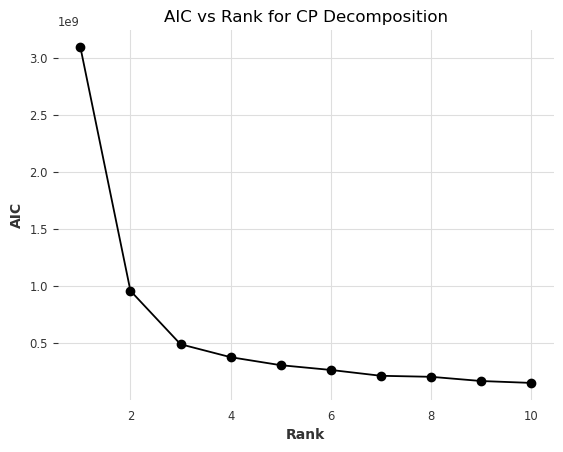

In [4]:
plt.plot(ranks, AIC_List, marker='o')
plt.xlabel('Rank')
plt.ylabel('AIC')
plt.title('AIC vs Rank for CP Decomposition')
plt.grid(True)
plt.show()

Based on the elbow diagram, we are opting to use a rank of 4, for easier interpretability.

In [5]:
weights, factors = parafac(train_tensor, rank =4, normalize_factors=True)
train_tensor.shape

time, complaint_types, community_boards = factors

time_array=time.detach().numpy() #needed for time series on time factor

The time matrices informs us of the influence that a given time period plays on a given component. In other words, we are uncovering 4 latent time patterns within the complaint dataset. When plotted, high complaint activity for a specific month-year is interpreted as a spike in the time series.

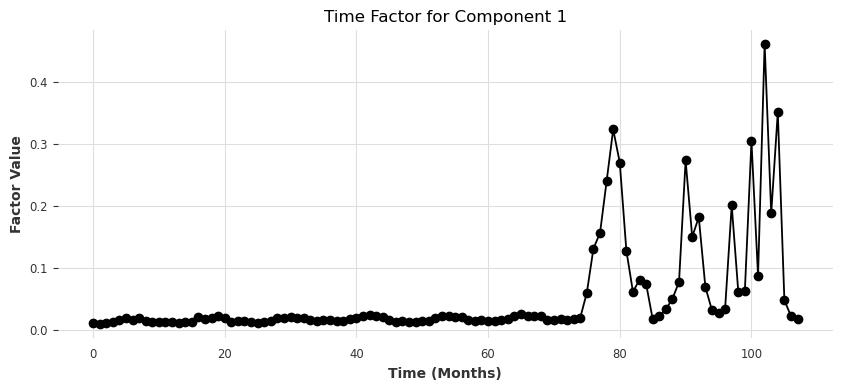

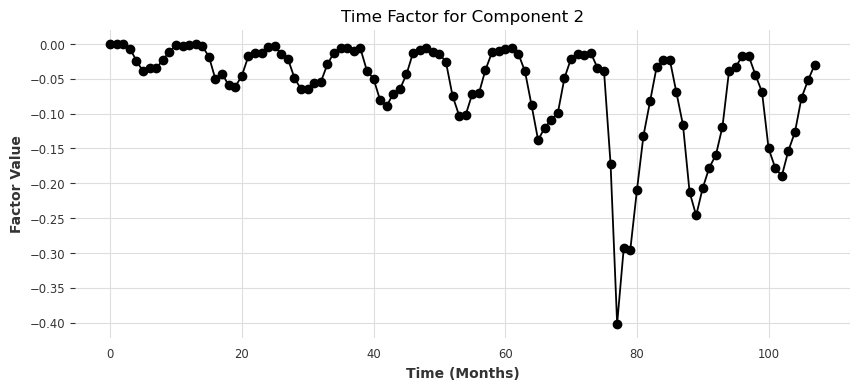

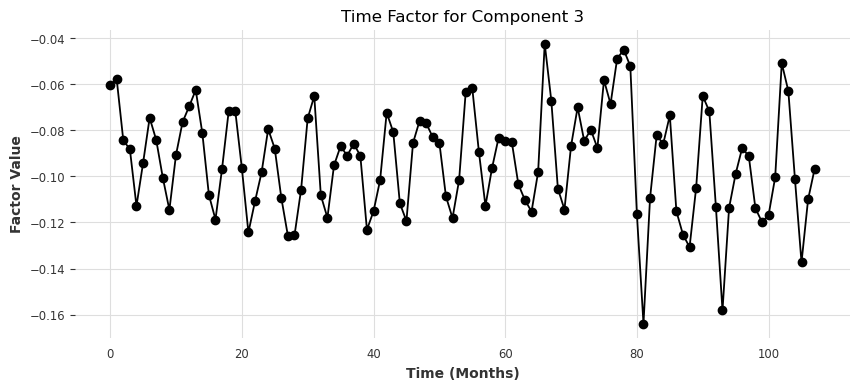

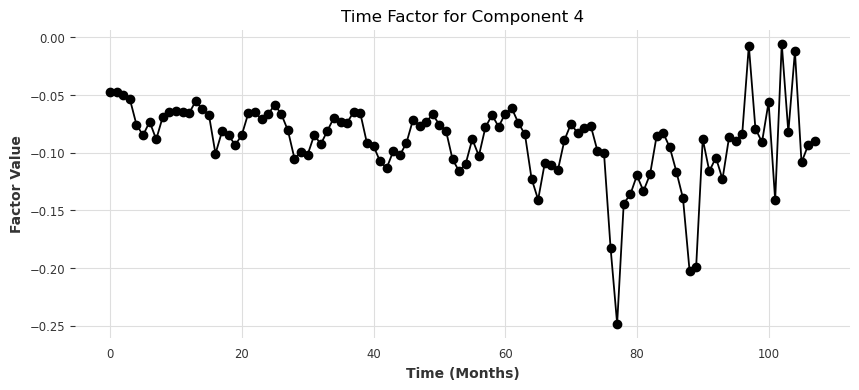

In [6]:
for r in range(4):
    plt.figure(figsize=(10, 4))
    plt.plot(time[:, r], marker='o')
    plt.title(f'Time Factor for Component {r+1}')
    plt.xlabel('Time (Months)')
    plt.ylabel('Factor Value')
    plt.grid(True)
    plt.show()

# 1. Baseline 311 Model

Generate estiamtes for the 4 components of the time factor


Rank 1:
Best season_length: 12


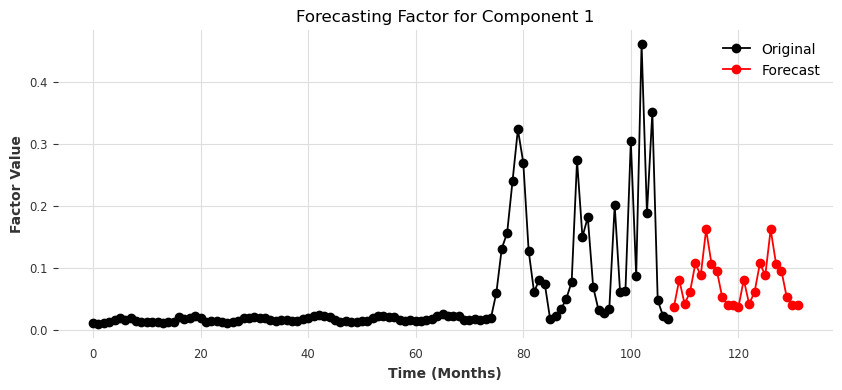


Rank 2:
Best season_length: 12


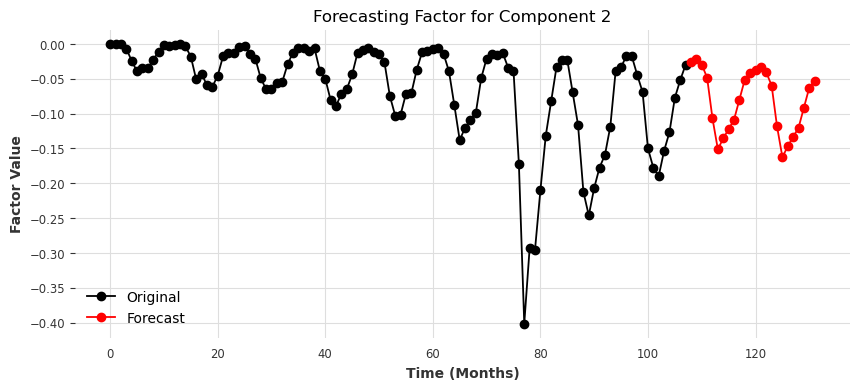


Rank 3:
Best season_length: 6


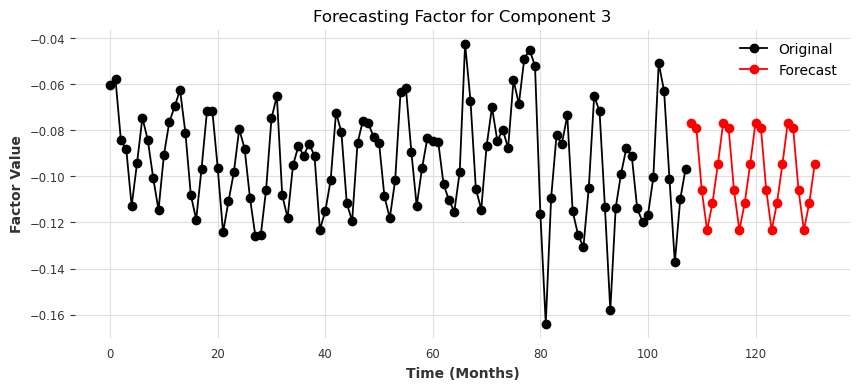


Rank 4:
Best season_length: 12


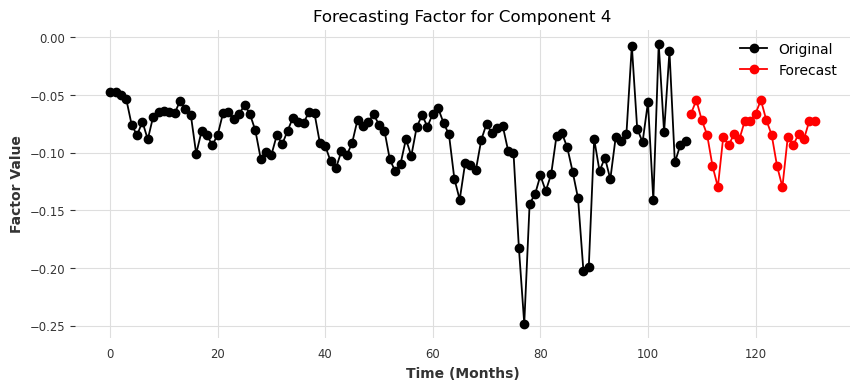

In [7]:
#############################################################
########## Dart's Gridsearch Method for AutoETS #############
#############################################################

factor_forecasts = []
time_index = pd.period_range(start='2014-01', end='2025-12', freq='M')

for r in range(4):
    from darts.metrics import mse, rmse
    param_grid = {
        'season_length': [3, 4, 6, 9, 12]
    }
    
    model = AutoETS()
    series = TimeSeries.from_times_and_values(
        time_index[:-36].to_timestamp(), 
        time_array[:, r].reshape(-1, 1)
    )  # 2014-2022
    
    # Add forecast_horizon for validation during grid search
    best_model, best_params, best_score = model.gridsearch(
        series=series,
        parameters=param_grid,
        forecast_horizon=12,  # Use 12 months for validation
        metric=mse # Can use rmse for model selection
    )
    
    print(f"\nRank {r+1}:")
    print(f"Best season_length: {best_params['season_length']}")
    
    # Train final model on full data with best parameters
    final_model = AutoETS(season_length=best_params['season_length'])
    final_model.fit(series)
    
    # Predict 2023-2025 (24 months)
    forecast = final_model.predict(24)
    factor_forecasts.append(forecast)

    # Plotting
    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(len(time_array[:, r])), time_array[:, r], 
             label='Original', marker='o')
    plt.plot(np.arange(len(time_array[:, r]), len(time_array[:, r]) + 24),
             forecast.values().flatten(), label='Forecast', marker='o', color='red')
    
    plt.title(f'Forecasting Factor for Component {r+1}')
    plt.xlabel('Time (Months)')
    plt.ylabel('Factor Value')
    plt.legend()
    plt.grid(True)
    plt.show()



In [8]:

RMSE_dict={}
MSE_dict = {}

In [9]:
factor_forecasts = np.array([fc.values().flatten() for fc in factor_forecasts]).T

extended_time_factor = np.vstack([time_array, factor_forecasts])
extended_factors = [tl.tensor(extended_time_factor), complaint_types, community_boards]
extended_reconstructed_tensor = cp_to_tensor((weights, extended_factors))


test_tensor = test_df.pivot_table(
    index='Year_Month', 
    columns=['Complaint Type', 'Community Board'], 
    values='count', 
    fill_value=0
).reindex(columns=pd.MultiIndex.from_product([all_complaint_types, all_community_boards], names=['Complaint Type', 'Community Board']), fill_value=0).values
test_tensor = test_tensor.reshape((test_tensor.shape[0], len(all_complaint_types), len(all_community_boards)))


estimate_time_tensor=extended_reconstructed_tensor[108:,:,:].flatten()
mse = mean_squared_error(test_tensor.flatten(), estimate_time_tensor)
rmse = np.sqrt(mse)
RMSE_dict['baseline_rmse'] = rmse
MSE_dict['baseline_mse'] = mse

print(f'Mean Squared Error on Test Set: {mse}')
print(f'Root Mean Squared Error on Test Set: {rmse}')


Mean Squared Error on Test Set: 63967.72775796661
Root Mean Squared Error on Test Set: 252.9184211518936


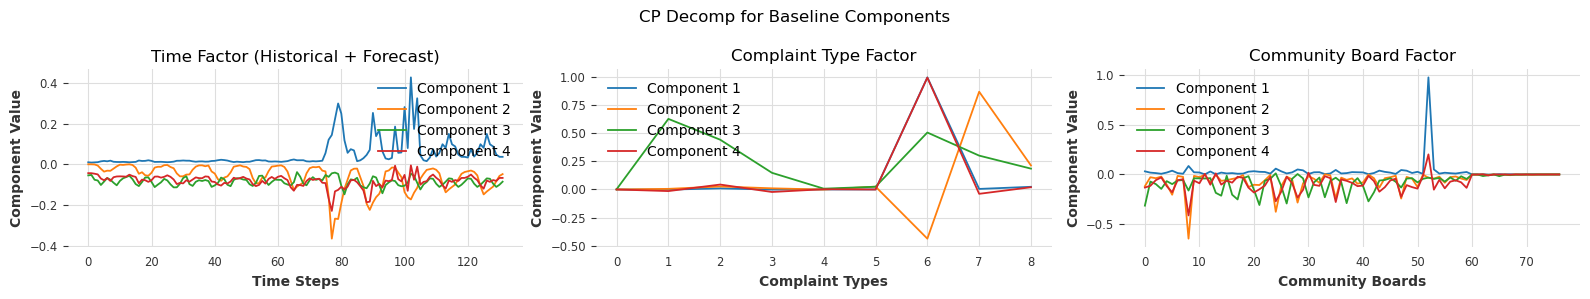

In [10]:

fig, axes = components_plot((weights, extended_factors))

axes[0].set_title("Time Factor (Historical + Forecast)")
axes[0].set_xlabel("Time Steps")
axes[0].set_ylabel("Component Value")

axes[1].set_title("Complaint Type Factor")
axes[1].set_xlabel("Complaint Types")
axes[1].set_ylabel("Component Value")

axes[2].set_title("Community Board Factor")
axes[2].set_xlabel("Community Boards")
axes[2].set_ylabel("Component Value")

fig.suptitle('CP Decomp for Baseline Components')

for ax in axes:
    lines = ax.get_lines()
    for i, line in enumerate(lines):
        line.set_color(plt.cm.tab10(i))
    ax.legend([f"Component {i+1}" for i in range(len(lines))], loc="best")

plt.tight_layout()
plt.show()


Create Dataframe for estimates over the test period

In [11]:
T_forecast, C, B = extended_reconstructed_tensor.shape  # e.g., 144, num_complaints, num_boards

first_month = pd.to_datetime(noise_complaints_complete['Year_Month'].min())
months = pd.date_range(start=first_month, periods=T_forecast, freq='MS')

estimated_counts = extended_reconstructed_tensor.flatten()

# Repeat months for each complaint_type × board
months_flat = np.repeat(months, C * B)  # length = T*C*B

# Repeat/ tile complaints and boards to match
complaints_flat = np.tile(np.repeat(all_complaint_types, B), T_forecast)
boards_flat = np.tile(all_community_boards, T_forecast * C)

# Create DataFrame
df_estimates = pd.DataFrame({
    'Year_Month': months_flat,
    'Complaint Type': complaints_flat,
    'Community Board': boards_flat,
    'estimated_count': estimated_counts
})

In [12]:
#df_estimates.to_csv('hist_actuals_estimates_base.csv')

Retrain on the full train + test set

In [13]:
noise_complaints_complete_tensor = noise_complaints_complete.pivot_table(index='Year_Month', columns=['Complaint Type', 'Community Board'], values='count', fill_value=0).values
noise_complaints_complete_tensor = noise_complaints_complete_tensor.reshape((noise_complaints_complete_tensor.shape[0], len(all_complaint_types), len(all_community_boards)))

noise_complaints_complete_tensor=tl.tensor(noise_complaints_complete_tensor)
weights_full, factors_full = parafac(noise_complaints_complete_tensor, rank=4, normalize_factors=True)

time_factors_full, complaint_types_full, community_boards_full = factors_full


Forecast for 12 months after the test period

Reconstruct the forecast tensor based on the future period

Convert back to a df for easier use

In [14]:

#############################################################
####### use tuned Dart's AutoETS with best_params from previous grid search 
#############################################################
time_factor_predictions = []
time_factors_full_array = time_factors_full.detach().numpy()

for r in range(4):
    from darts.metrics import mse, rmse
    series = TimeSeries.from_values(time_factors_full_array[:, r].reshape(-1, 1))
    model = AutoETS(season_length=best_params['season_length'])
    model.fit(series)
    
    forecast = model.predict(12)
    time_factor_predictions.append(forecast.values().flatten())

time_factor_predictions = tl.tensor(np.column_stack(time_factor_predictions))

reconstructed_tensor_predictions = cp_to_tensor((weights_full, [time_factor_predictions, complaint_types_full, community_boards_full]))
reconstructed_tensor_full = cp_to_tensor((weights_full, [tl.tensor(np.vstack([time_factors_full, time_factor_predictions])), complaint_types_full, community_boards_full]))

T_forecast, C, B = reconstructed_tensor_predictions.shape  # e.g., 12, num_complaints, num_boards

last_month = pd.to_datetime(noise_complaints_complete['Year_Month'].max())
months = pd.date_range(start=last_month + pd.offsets.MonthBegin(), periods=T_forecast, freq='MS')

predicted_counts = reconstructed_tensor_predictions.flatten()

# Repeat months for each complaint_type × board
months_flat = np.repeat(months, C * B)  # length = T*C*B

# Repeat/ tile complaints and boards to match
complaints_flat = np.tile(np.repeat(all_complaint_types, B), T_forecast)
boards_flat = np.tile(all_community_boards, T_forecast * C)

# Create DataFrame
df_forecast = pd.DataFrame({
    'Year_Month': months_flat,
    'Complaint Type': complaints_flat,
    'Community Board': boards_flat,
    'predicted_count': predicted_counts
})


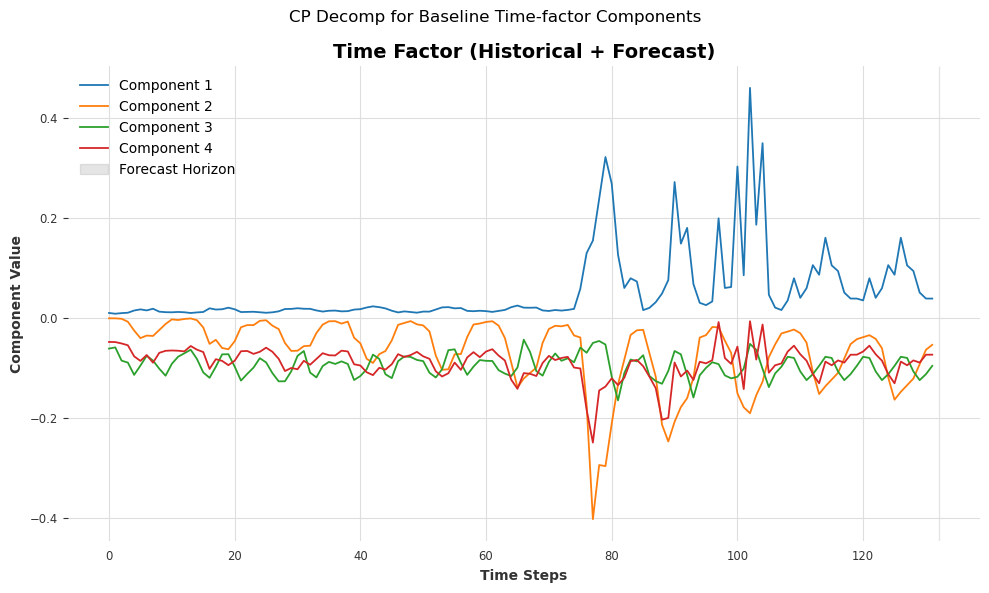

In [15]:
time_factor = extended_factors[0] 

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(time_factor.shape[1]): 
    ax.plot(range(time_factor.shape[0]), time_factor[:, i], color=plt.cm.tab10(i), label=f"Component {i+1}")

ax.set_title("Time Factor (Historical + Forecast)", fontsize=14, fontweight='bold')
ax.set_xlabel("Time Steps")
ax.set_ylabel("Component Value")

forecast_start = time_factors_full_array.shape[0]
forecast_end = extended_time_factor.shape[0]
ax.axvspan(forecast_start, forecast_end, color='gray', alpha=0.2, label="Forecast Horizon")

ax.legend(loc="best")

plt.suptitle('CP Decomp for Baseline Time-factor Components')

plt.tight_layout()
plt.show()

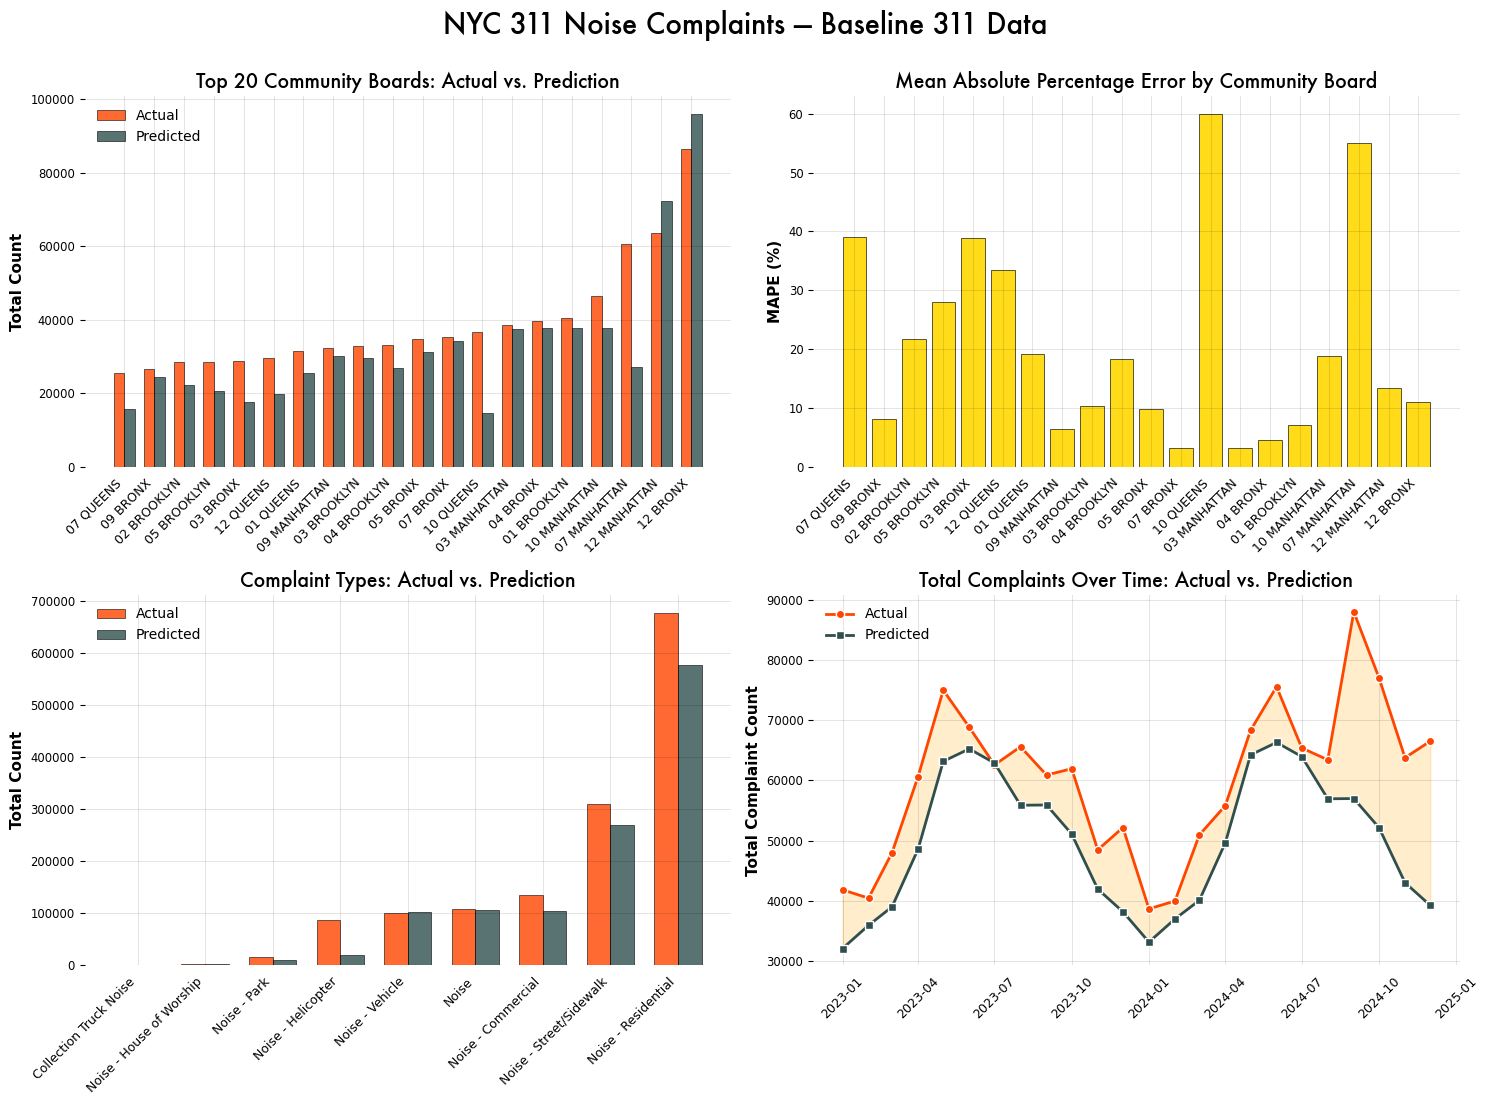

In [16]:
# Convert PyTorch tensor to NumPy at the beginning

extended_reconstructed_np = extended_reconstructed_tensor.detach().numpy()
estimate_time_tensor_np = extended_reconstructed_np[108:,:,:].flatten()

test_months = pd.date_range(start='2023-01', periods=test_tensor.shape[0], freq='MS')

# Data for Community Board plots
actual_by_board = test_tensor.sum(axis=(0, 1))
predicted_by_board = extended_reconstructed_np[108:108+test_tensor.shape[0], :, :].sum(axis=(0, 1))
mape_by_board = np.abs((actual_by_board - predicted_by_board) / 
                       (actual_by_board + 1e-10)) * 100
top_boards_idx = np.argsort(actual_by_board)[-20:]

# Data for Complaint Type plot
actual_by_complaint = test_tensor.sum(axis=(0, 2))
predicted_by_complaint = extended_reconstructed_np[108:108+test_tensor.shape[0], :, :].sum(axis=(0, 2))
top_complaints_idx = np.argsort(actual_by_complaint)[:]
top_complaints = all_complaint_types[top_complaints_idx]

# Data for Time Series plot
actual_by_time = test_tensor.sum(axis=(1, 2))
predicted_by_time = extended_reconstructed_np[108:108+test_tensor.shape[0], :, :].sum(axis=(1, 2))

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

fig.suptitle(
    "NYC 311 Noise Complaints — Baseline 311 Data",
    fontsize=20,
    fontweight='bold',
    fontfamily='Futura', 
    y=1      # adjust vertical position
)
for ax in axes.ravel():
    ax.tick_params(axis='both', colors='black')
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')

# TOP LEFT: Community Board Barchart
x_pos_board = np.arange(len(top_boards_idx))
width = 0.35
axes[0, 0].bar(x_pos_board - width/2, actual_by_board[top_boards_idx], 
               width, label='Actual', alpha=0.8, color='#FF4500', 
               edgecolor='black', linewidth=0.5)
axes[0, 0].bar(x_pos_board + width/2, predicted_by_board[top_boards_idx], 
               width, label='Predicted', alpha=0.8, color='#2F4F4F',
               edgecolor='black', linewidth=0.5)
#axes[0, 0].set_xlabel('Community Board', fontsize=11)
axes[0, 0].set_ylabel('Total Count', fontsize=11)
axes[0, 0].set_title('Top 20 Community Boards: Actual vs. Prediction', fontsize=14, fontweight='bold', fontfamily='Futura')
axes[0, 0].set_xticks(x_pos_board)
axes[0, 0].set_xticklabels(all_community_boards[top_boards_idx], rotation=45, ha='right', fontsize=9)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.1, color='black')

# TOP RIGHT: Community Board - MAPE
axes[0, 1].bar(x_pos_board, mape_by_board[top_boards_idx], alpha=0.9, color='#FFD700',
               edgecolor='black', linewidth=0.5)
#axes[0, 1].set_xlabel('Community Board', fontsize=11)
axes[0, 1].set_ylabel('MAPE (%)', fontsize=11)
axes[0, 1].set_title('Mean Absolute Percentage Error by Community Board', fontsize=14, fontweight='bold', fontfamily='Futura')
axes[0, 1].set_xticks(x_pos_board)
axes[0, 1].set_xticklabels(all_community_boards[top_boards_idx], rotation=45, ha='right', fontsize=9)
axes[0, 1].grid(True, alpha=0.1, color='black')

# BOTTOM LEFT: Complaint Type - Actual vs Predicted
x_pos_complaint = np.arange(len(top_complaints))
axes[1, 0].bar(x_pos_complaint - width/2, actual_by_complaint[top_complaints_idx], 
               width, label='Actual', alpha=0.8, color='#FF4500',
               edgecolor='black', linewidth=0.5)
axes[1, 0].bar(x_pos_complaint + width/2, predicted_by_complaint[top_complaints_idx], 
               width, label='Predicted', alpha=0.8, color='#2F4F4F',
               edgecolor='black', linewidth=0.5)
# axes[1, 0].set_xlabel('Complaint Type', fontsize=11)
axes[1, 0].set_ylabel('Total Count', fontsize=11)
axes[1, 0].set_title('Complaint Types: Actual vs. Prediction', fontsize=14, fontweight='bold', fontfamily='Futura')
axes[1, 0].set_xticks(x_pos_complaint)
axes[1, 0].set_xticklabels(top_complaints, rotation=45, ha='right', fontsize=9)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.1, color='black')

# BOTTOM RIGHT: Time Series - Actual vs Predicted Over Time
axes[1, 1].plot(test_months, actual_by_time, marker='o', label='Actual', 
                linewidth=2, markersize=6, color='#FF4500',  markeredgecolor='white')
axes[1, 1].plot(test_months, predicted_by_time, marker='s', label='Predicted', 
                linewidth=2, markersize=6, color='#2F4F4F', markeredgecolor='white')
axes[1, 1].fill_between(test_months, actual_by_time, predicted_by_time, alpha=0.2, color='#FFA500')
# axes[1, 1].set_xlabel('Month', fontsize=11)
axes[1, 1].set_ylabel('Total Complaint Count', fontsize=11)
axes[1, 1].set_title('Total Complaints Over Time: Actual vs. Prediction', fontsize=14, fontweight='bold', fontfamily='Futura')
axes[1, 1].legend(fontsize=10, loc='best')
axes[1, 1].grid(True, alpha=0.1, color='black')
axes[1, 1].tick_params(axis='x', rotation=45, labelsize=9)

plt.tight_layout()
plt.savefig('NYC311_Results_Baseline.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
#df_forecast.to_csv('forecasts_base.csv')
#df_estimates.to_csv('hist_actuals_estimates_base.csv')

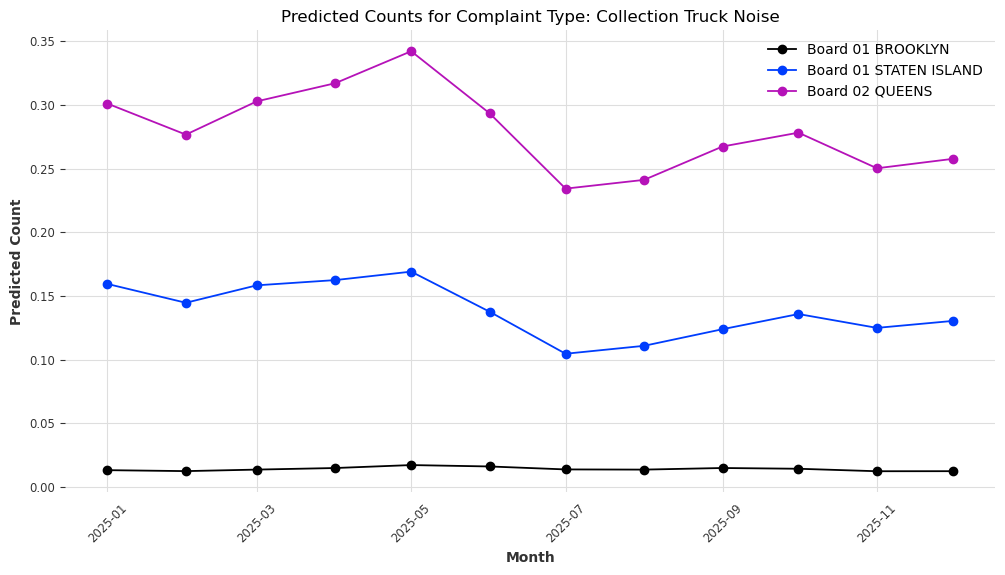

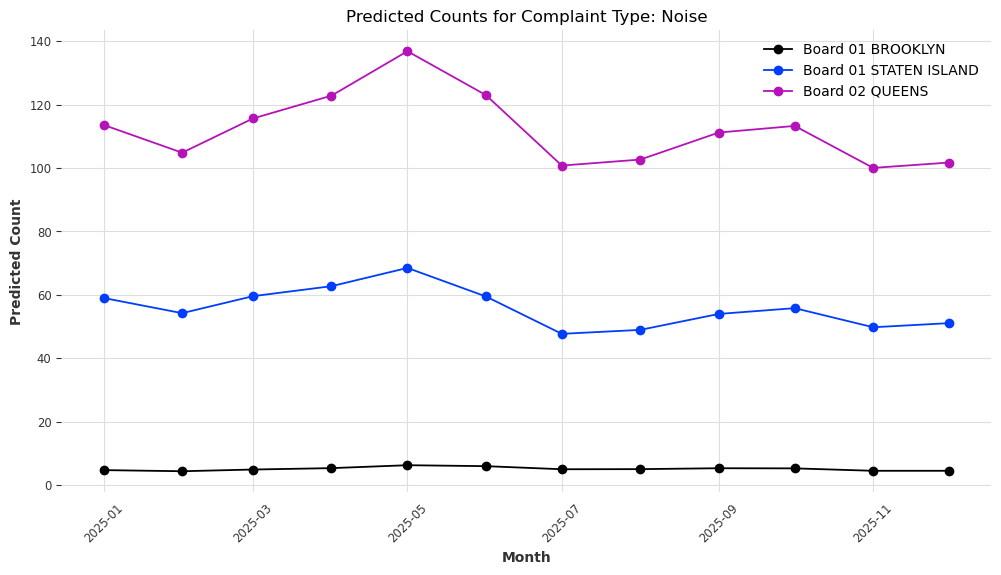

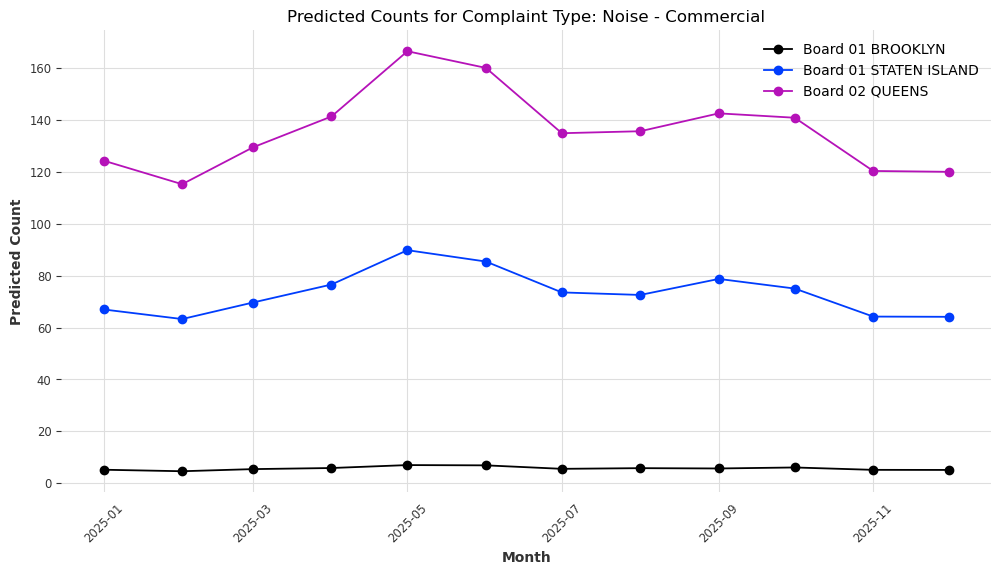

In [18]:
#Visualize and summarize the predictions for different complaint types and locations
for complaint in all_complaint_types[:3]:  # Visualize first 3 complaint types
    plt.figure(figsize=(12, 6))
    subset = df_forecast[df_forecast['Complaint Type'] == complaint]
    for board in all_community_boards[:3]:  # Visualize first 3 community boards
        board_subset = subset[subset['Community Board'] == board]
        plt.plot(board_subset['Year_Month'], board_subset['predicted_count'], marker='o', label=f'Board {board}')
    plt.title(f'Predicted Counts for Complaint Type: {complaint}')
    plt.xlabel('Month')
    plt.ylabel('Predicted Count')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.show()

# 3. Baseline 311 + Construction Counts

Counts of Active Work

Add in key to tie BoroCD with community board

In [19]:
monthly_active_work_counts = pd.read_csv('data/monthly_active_work_counts.csv')
monthly_active_work_counts=monthly_active_work_counts.melt(id_vars=['date'], var_name = 'primary_cd',value_name = 'active_work_counts')

#drop Unknown boroCD rows
monthly_active_work_counts = monthly_active_work_counts[monthly_active_work_counts['primary_cd'] != 'Unknown']

monthly_active_work_counts['primary_cd'] = monthly_active_work_counts['primary_cd'].astype(int)

boroCD_key=pd.read_csv('data/lookup_boroCD_community_board.csv')
boroCD_key=boroCD_key.iloc[:,:2]
boroCD_key['Community Board']=boroCD_key['Community Board'].astype(str)
display(boroCD_key.head(2))

monthly_active_work_counts['date'] = monthly_active_work_counts['date'].astype(str)
monthly_active_work_counts_withCommunityBoard=monthly_active_work_counts.merge(boroCD_key, left_on='primary_cd', right_on='BoroCD', how='left').drop(columns=['BoroCD'])

noise_complaints_complete=noise_complaints_complete.merge(monthly_active_work_counts_withCommunityBoard, left_on=['Year_Month', 'Community Board'], right_on=['date', 'Community Board'], how='left').fillna(0).drop(columns=['date','primary_cd'])

noise_complaints_complete['active_work_counts'].max()

monthly_active_work_counts_grouped_array=monthly_active_work_counts[['date','active_work_counts']].drop_duplicates().groupby('date')['active_work_counts'].sum().sort_index().values
monthly_active_work_counts_grouped_2025_array=monthly_active_work_counts_grouped_array[-12:] #get 2025
monthly_active_work_counts_grouped_2012_2024=monthly_active_work_counts_grouped_array[:-12] #remove 2025

,BoroCD,Community Board
0,101,01 MANHATTAN
1,102,02 MANHATTAN


for each component in the time factor, we want to create a time series forecast based on the auto ETS model with a future covariate (ex. active work counts)


Rank 1:
Best season_length: 12


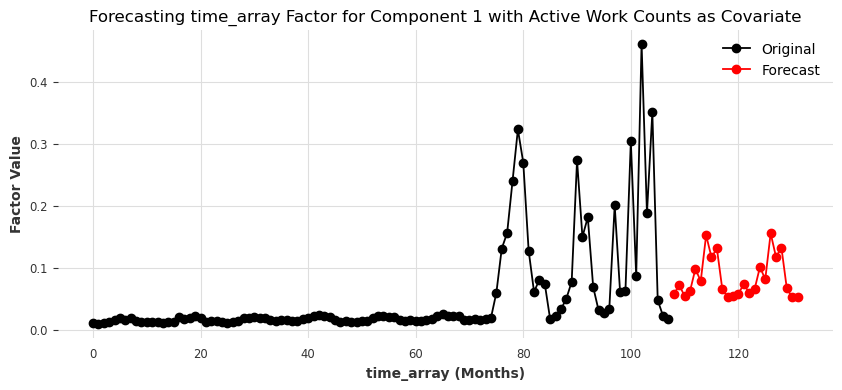


Rank 2:
Best season_length: 12


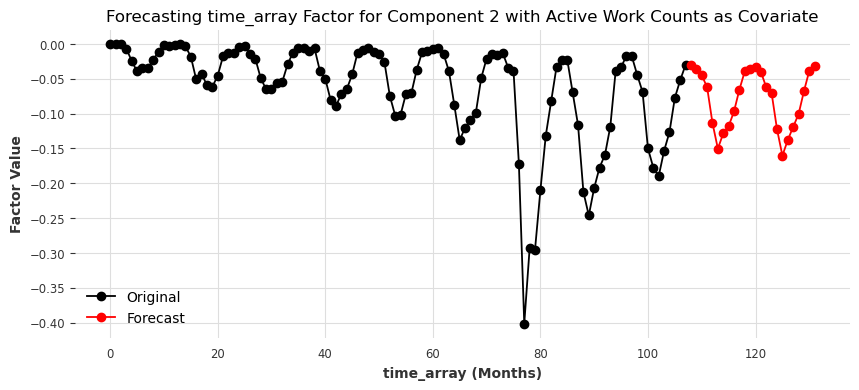


Rank 3:
Best season_length: 6


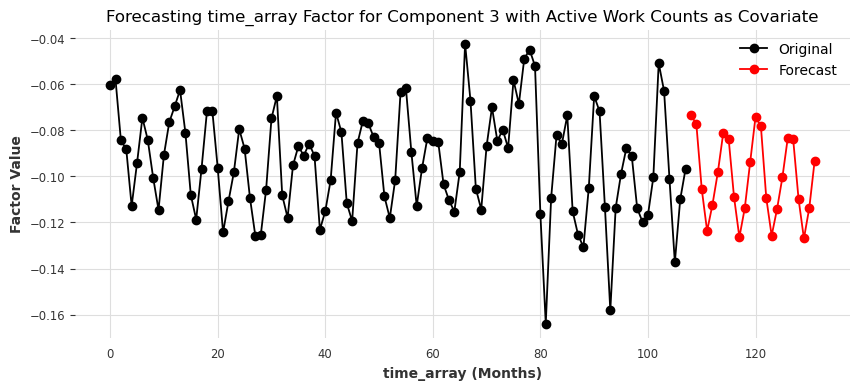


Rank 4:
Best season_length: 12


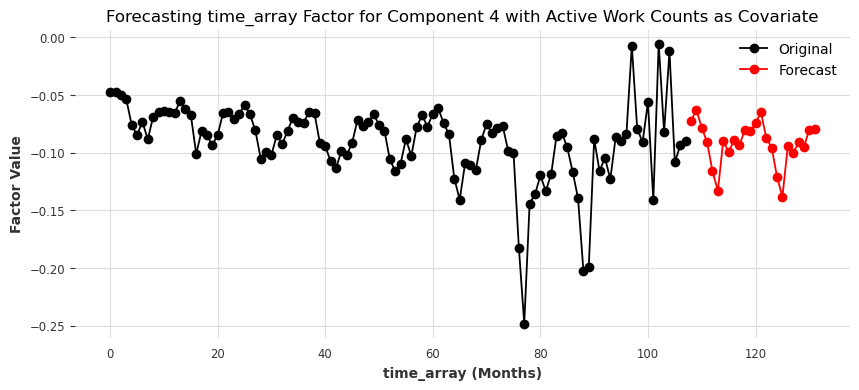

In [20]:
#############################################################
########## Dart's Gridsearch Method for AutoETS #############
#############################################################

factor_forecasts_active_work_counts = []
time_index = pd.period_range(start='2014-01', end='2025-12', freq='M')
future_covariate = TimeSeries.from_times_and_values(
    time_index.to_timestamp(), 
    monthly_active_work_counts_grouped_array.reshape(-1, 1)
)  # 2014-2025

for r in range(4):
    from darts.metrics import mse, rmse

    series = TimeSeries.from_times_and_values(
        time_index[:-36].to_timestamp(), 
        time_array[:, r].reshape(-1, 1)
    )  # 2014-2022
    
    # Grid search for best season_length using expanding window
    parameters_dict = {'season_length': [3, 4, 6, 9, 12]}

    model = AutoETS()
    
    best_model, best_params, best_score = model.gridsearch(
        parameters=parameters_dict,
        series=series,  # Full training data 2014-2022
        future_covariates=future_covariate[:-36],  # Covariates 2014-2022
        forecast_horizon=12,  # Predict 12 months ahead at each step
        stride=12,  # Move 12 months forward between predictions
        metric=mse  #  Use MSE for model selection
    )
    
    print(f"\nRank {r+1}:")
    print(f"Best season_length: {best_params['season_length']}")
    
    # Train final model on full data with best parameters
    final_model = AutoETS(season_length=best_params['season_length'])
    final_model.fit(series, future_covariates=future_covariate[:-36])
    
    # Predict 2023-2025
    forecast = final_model.predict(24, future_covariates=future_covariate)
    factor_forecasts_active_work_counts.append(forecast)
    
    # Plotting
    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(len(time_array[:, r])), time_array[:, r], 
             label='Original', marker='o')
    plt.plot(np.arange(len(time_array[:, r]), len(time_array[:, r]) + 24),
             forecast.values(), label='Forecast', marker='o', color='red')
    plt.title(f'Forecasting time_array Factor for Component {r+1} with Active Work Counts as Covariate')
    plt.xlabel('time_array (Months)')
    plt.ylabel('Factor Value')
    plt.legend()
    plt.grid(True)
    plt.show()

In [21]:
#calculate RMSE on 2023-2024 using active work counts adjusted forecasts, recall it's list of TimeSeries
factor_forecasts_active_work_counts = np.array([fc.values().flatten() for fc in factor_forecasts_active_work_counts]).T

extended_time_factor = np.vstack([time_array, factor_forecasts_active_work_counts])
extended_factors = [tl.tensor(extended_time_factor), complaint_types, community_boards]
extended_reconstructed_tensor = cp_to_tensor((weights, extended_factors))
test_tensor = test_df.pivot_table(
    index='Year_Month', 
    columns=['Complaint Type', 'Community Board'], 
    values='count', 
    fill_value=0
).reindex(columns=pd.MultiIndex.from_product([all_complaint_types, all_community_boards], names=['Complaint Type', 'Community Board']), fill_value=0).values
test_tensor = test_tensor.reshape((test_tensor.shape[0], len(all_complaint_types), len(all_community_boards)))


estimate_time_tensor=extended_reconstructed_tensor[108:,:,:].flatten()
mse = mean_squared_error(test_tensor.flatten(), estimate_time_tensor)
rmse = np.sqrt(mse)
RMSE_dict['counts_active_work_rmse'] = rmse
MSE_dict['counts_active_work_mse'] = mse
print(f'Mean Squared Error on Test Set: {mse}')
print(f'Root Mean Squared Error on Test Set: {rmse}')

Mean Squared Error on Test Set: 59041.99654414576
Root Mean Squared Error on Test Set: 242.98558916969904


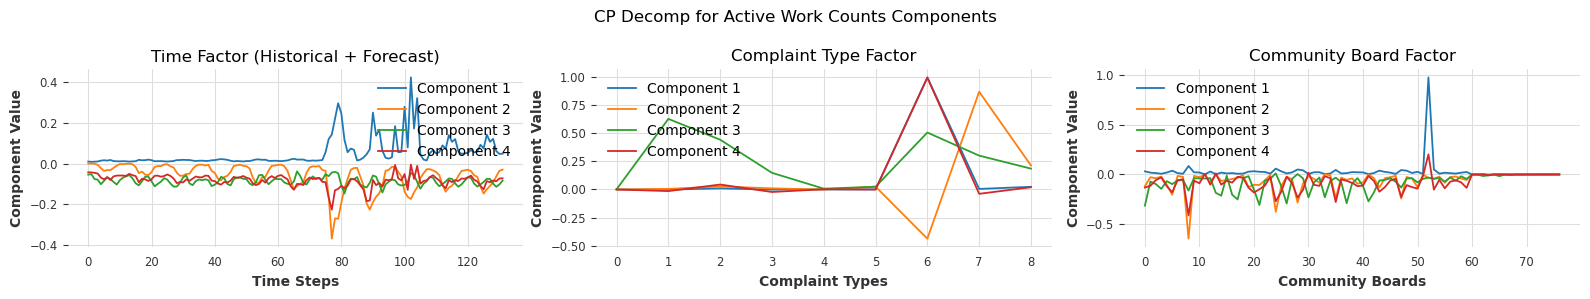

In [22]:

fig, axes = components_plot((weights, extended_factors))

axes[0].set_title("Time Factor (Historical + Forecast)")
axes[0].set_xlabel("Time Steps")
axes[0].set_ylabel("Component Value")

axes[1].set_title("Complaint Type Factor")
axes[1].set_xlabel("Complaint Types")
axes[1].set_ylabel("Component Value")

axes[2].set_title("Community Board Factor")
axes[2].set_xlabel("Community Boards")
axes[2].set_ylabel("Component Value")

fig.suptitle('CP Decomp for Active Work Counts Components')

for ax in axes:
    lines = ax.get_lines()
    for i, line in enumerate(lines):
        line.set_color(plt.cm.tab10(i))
    ax.legend([f"Component {i+1}" for i in range(len(lines))], loc="best")

plt.tight_layout()
plt.show()

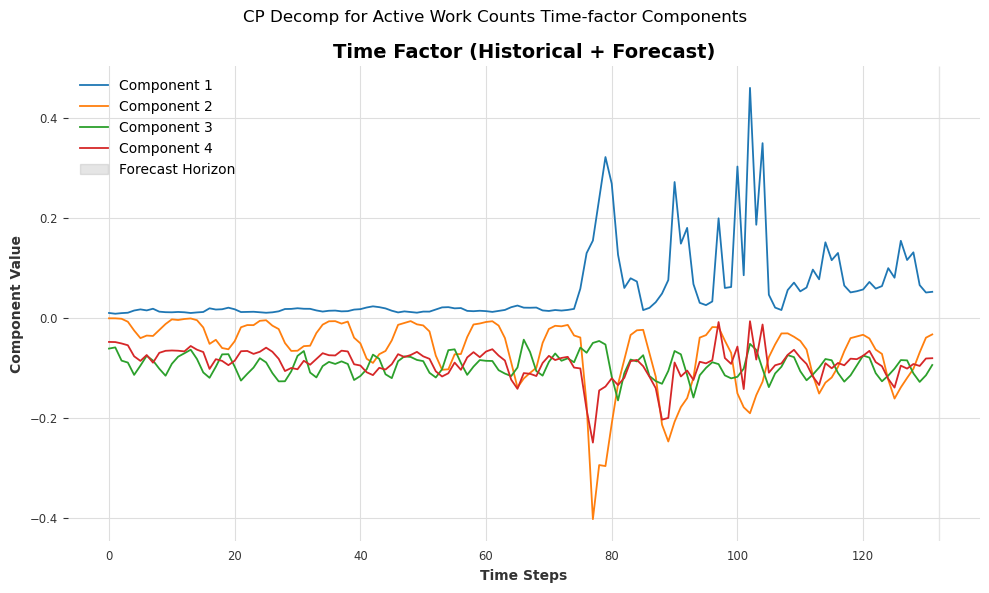

In [23]:
time_factor = extended_factors[0] 

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(time_factor.shape[1]): 
    ax.plot(range(time_factor.shape[0]), time_factor[:, i], color=plt.cm.tab10(i), label=f"Component {i+1}")

ax.set_title("Time Factor (Historical + Forecast)", fontsize=14, fontweight='bold')
ax.set_xlabel("Time Steps")
ax.set_ylabel("Component Value")

forecast_start = time_factors_full_array.shape[0]
forecast_end = extended_time_factor.shape[0]
ax.axvspan(forecast_start, forecast_end, color='gray', alpha=0.2, label="Forecast Horizon")

ax.legend(loc="best")

plt.suptitle('CP Decomp for Active Work Counts Time-factor Components')

plt.tight_layout()
plt.show()

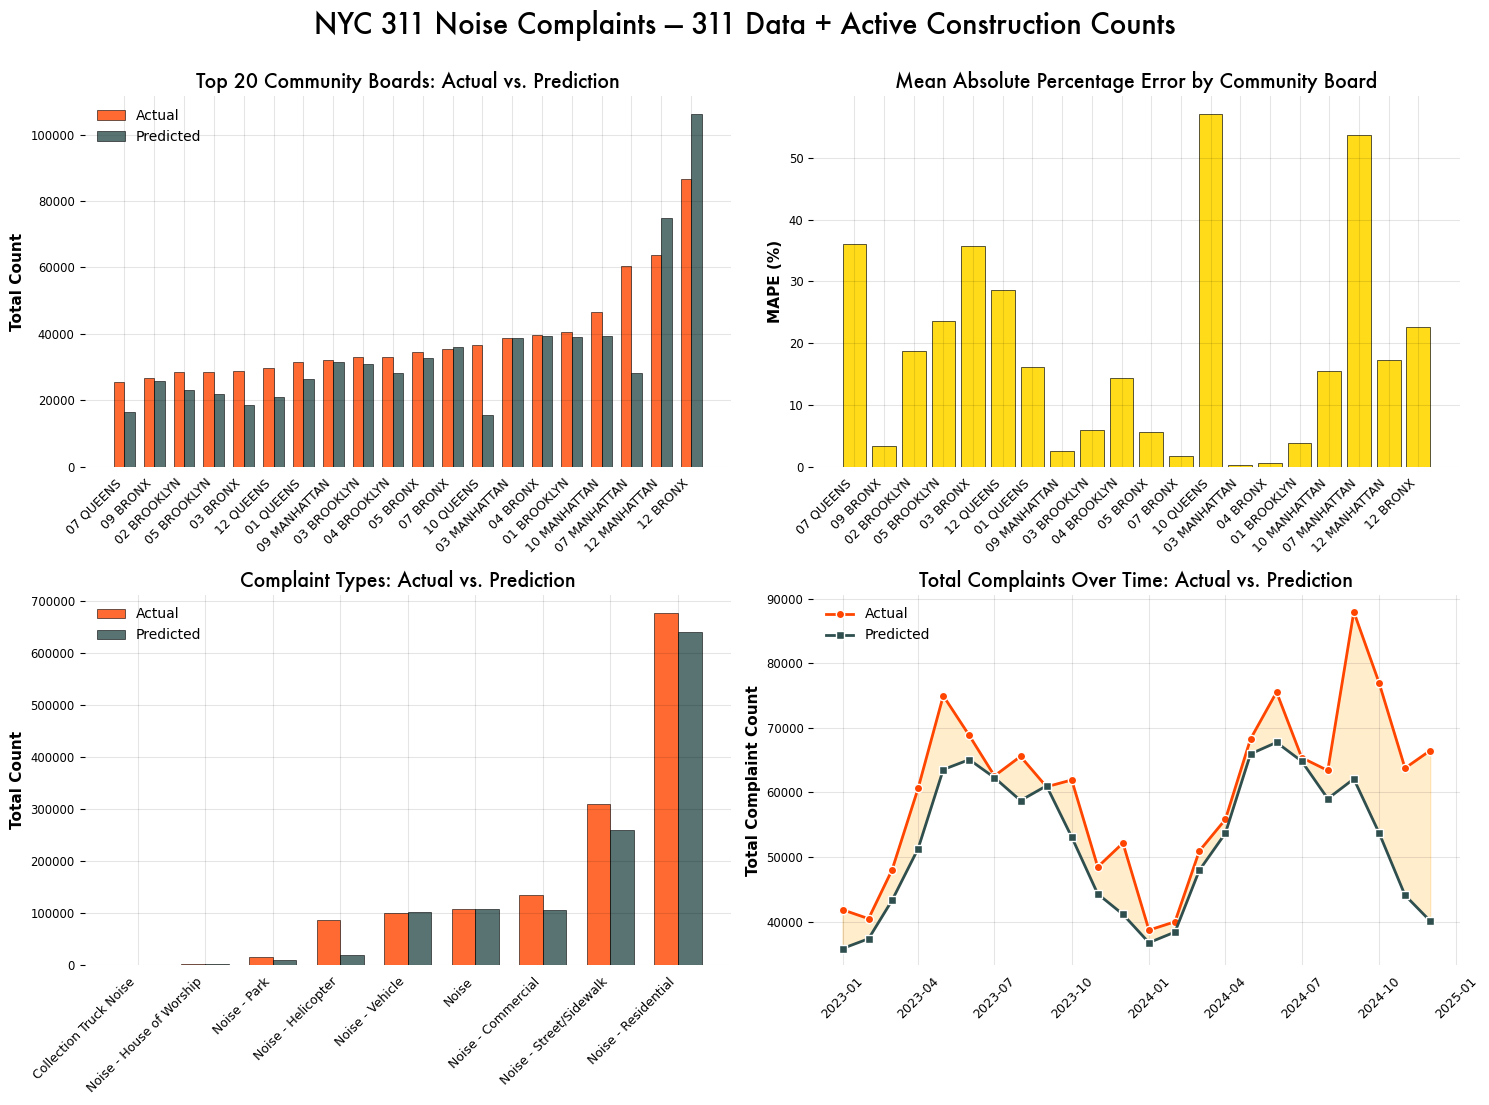

In [24]:
# Convert PyTorch tensor to NumPy at the beginning
extended_reconstructed_np = extended_reconstructed_tensor.detach().numpy()
estimate_time_tensor_np = extended_reconstructed_np[108:,:,:].flatten()

test_months = pd.date_range(start='2023-01', periods=test_tensor.shape[0], freq='MS')

# Data for Community Board plots
actual_by_board = test_tensor.sum(axis=(0, 1))
predicted_by_board = extended_reconstructed_np[108:108+test_tensor.shape[0], :, :].sum(axis=(0, 1))
mape_by_board = np.abs((actual_by_board - predicted_by_board) / 
                       (actual_by_board + 1e-10)) * 100
top_boards_idx = np.argsort(actual_by_board)[-20:]

# Data for Complaint Type plot
actual_by_complaint = test_tensor.sum(axis=(0, 2))
predicted_by_complaint = extended_reconstructed_np[108:108+test_tensor.shape[0], :, :].sum(axis=(0, 2))
top_complaints_idx = np.argsort(actual_by_complaint)[:]
top_complaints = all_complaint_types[top_complaints_idx]

# Data for Time Series plot
actual_by_time = test_tensor.sum(axis=(1, 2))
predicted_by_time = extended_reconstructed_np[108:108+test_tensor.shape[0], :, :].sum(axis=(1, 2))

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

fig.suptitle(
    "NYC 311 Noise Complaints — 311 Data + Active Construction Counts",
    fontsize=20,
    fontweight='bold',
    fontfamily='Futura', 
    y=1      # adjust vertical position
)
for ax in axes.ravel():
    ax.tick_params(axis='both', colors='black')
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')

# TOP LEFT: Community Board Barchart
x_pos_board = np.arange(len(top_boards_idx))
width = 0.35
axes[0, 0].bar(x_pos_board - width/2, actual_by_board[top_boards_idx], 
               width, label='Actual', alpha=0.8, color='#FF4500', 
               edgecolor='black', linewidth=0.5)
axes[0, 0].bar(x_pos_board + width/2, predicted_by_board[top_boards_idx], 
               width, label='Predicted', alpha=0.8, color='#2F4F4F',
               edgecolor='black', linewidth=0.5)
#axes[0, 0].set_xlabel('Community Board', fontsize=11)
axes[0, 0].set_ylabel('Total Count', fontsize=11)
axes[0, 0].set_title('Top 20 Community Boards: Actual vs. Prediction', fontsize=14, fontweight='bold', fontfamily='Futura')
axes[0, 0].set_xticks(x_pos_board)
axes[0, 0].set_xticklabels(all_community_boards[top_boards_idx], rotation=45, ha='right', fontsize=9)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.1, color='black')

# TOP RIGHT: Community Board - MAPE
axes[0, 1].bar(x_pos_board, mape_by_board[top_boards_idx], alpha=0.9, color='#FFD700',
               edgecolor='black', linewidth=0.5)
#axes[0, 1].set_xlabel('Community Board', fontsize=11)
axes[0, 1].set_ylabel('MAPE (%)', fontsize=11)
axes[0, 1].set_title('Mean Absolute Percentage Error by Community Board', fontsize=14, fontweight='bold', fontfamily='Futura')
axes[0, 1].set_xticks(x_pos_board)
axes[0, 1].set_xticklabels(all_community_boards[top_boards_idx], rotation=45, ha='right', fontsize=9)
axes[0, 1].grid(True, alpha=0.1, color='black')

# BOTTOM LEFT: Complaint Type - Actual vs Predicted
x_pos_complaint = np.arange(len(top_complaints))
axes[1, 0].bar(x_pos_complaint - width/2, actual_by_complaint[top_complaints_idx], 
               width, label='Actual', alpha=0.8, color='#FF4500',
               edgecolor='black', linewidth=0.5)
axes[1, 0].bar(x_pos_complaint + width/2, predicted_by_complaint[top_complaints_idx], 
               width, label='Predicted', alpha=0.8, color='#2F4F4F',
               edgecolor='black', linewidth=0.5)
# axes[1, 0].set_xlabel('Complaint Type', fontsize=11)
axes[1, 0].set_ylabel('Total Count', fontsize=11)
axes[1, 0].set_title('Complaint Types: Actual vs. Prediction', fontsize=14, fontweight='bold', fontfamily='Futura')
axes[1, 0].set_xticks(x_pos_complaint)
axes[1, 0].set_xticklabels(top_complaints, rotation=45, ha='right', fontsize=9)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.1, color='black')

# BOTTOM RIGHT: Time Series - Actual vs Predicted Over Time
axes[1, 1].plot(test_months, actual_by_time, marker='o', label='Actual', 
                linewidth=2, markersize=6, color='#FF4500',  markeredgecolor='white')
axes[1, 1].plot(test_months, predicted_by_time, marker='s', label='Predicted', 
                linewidth=2, markersize=6, color='#2F4F4F', markeredgecolor='white')
axes[1, 1].fill_between(test_months, actual_by_time, predicted_by_time, alpha=0.2, color='#FFA500')
# axes[1, 1].set_xlabel('Month', fontsize=11)
axes[1, 1].set_ylabel('Total Complaint Count', fontsize=11)
axes[1, 1].set_title('Total Complaints Over Time: Actual vs. Prediction', fontsize=14, fontweight='bold', fontfamily='Futura')
axes[1, 1].legend(fontsize=10, loc='best')
axes[1, 1].grid(True, alpha=0.1, color='black')
axes[1, 1].tick_params(axis='x', rotation=45, labelsize=9)

plt.tight_layout()
plt.savefig('NYC311_Results_Baseline_Construction_Count.png', dpi=300, bbox_inches='tight')
plt.show()

Notice we see a lower MSQE and a lower RMSE

Create a dataframe for estimates over the test period

In [25]:
T_forecast, C, B = extended_reconstructed_tensor.shape  # e.g., 144, num_complaints, num_boards

first_month = pd.to_datetime(noise_complaints_complete['Year_Month'].min())
months = pd.date_range(start=first_month, periods=T_forecast, freq='MS')

estimated_counts = extended_reconstructed_tensor.flatten()

# Repeat months for each complaint_type × board
months_flat = np.repeat(months, C * B)  # length = T*C*B

# Repeat/ tile complaints and boards to match
complaints_flat = np.tile(np.repeat(all_complaint_types, B), T_forecast)
boards_flat = np.tile(all_community_boards, T_forecast * C)

# Create DataFrame
df_estimates = pd.DataFrame({
    'Year_Month': months_flat,
    'Complaint Type': complaints_flat,
    'Community Board': boards_flat,
    'estimated_count': estimated_counts
})

In [26]:
#df_estimates.to_csv('hist_actuals_estimates_activeworkcounts.csv')

Let's Retrain on the full train + test

In [27]:
noise_complaints_complete_tensor = noise_complaints_complete.pivot_table(index='Year_Month', columns=['Complaint Type', 'Community Board'], values='count', fill_value=0).values
noise_complaints_complete_tensor = noise_complaints_complete_tensor.reshape((noise_complaints_complete_tensor.shape[0], len(all_complaint_types), len(all_community_boards)))

noise_complaints_complete_tensor=tl.tensor(noise_complaints_complete_tensor)
weights_full, factors_full = parafac(noise_complaints_complete_tensor, rank=4, normalize_factors=True)

time_factors_full, complaint_types_full, community_boards_full = factors_full


Forecast for 12 months after the test period

In [28]:

#############################################################
####### use tuned Dart's AutoETS with best_params from previous grid search for forecast
#############################################################

factor_forecasts_active_work_counts_full_array = []
time_factors_full_array=time_factors_full.detach().numpy()
time_index = pd.period_range(start='2014-01', end='2025-12', freq='M')
future_covariate= TimeSeries.from_times_and_values(time_index.to_timestamp(), monthly_active_work_counts_grouped_array.reshape(-1,1)) #2012-2025


for r in range(4):
    series = TimeSeries.from_times_and_values(
        time_index[:-12].to_timestamp(), 
        time_factors_full_array[:, r].reshape(-1,1)
    )  # 2014-2022

    model = AutoETS(season_length=best_params['season_length'])
    
    model.fit(series, future_covariates = future_covariate[:-12]) #Future covariates up to end of 2024
    forecast = model.predict(12, future_covariates = future_covariate) #predict 2025, provide future covariates
    factor_forecasts_active_work_counts_full_array.append(forecast)

# time_factor_predictions = tl.tensor(np.column_stack(time_factor_predictions))


Folded that back into the tensor and create predictions

In [29]:
factor_forecasts_active_work_counts_full_array = np.array([fc.values().flatten() for fc in factor_forecasts_active_work_counts_full_array]).T
extended_time_factor = np.vstack([time_factors_full_array, factor_forecasts_active_work_counts_full_array])
extended_factors = [tl.tensor(extended_time_factor), complaint_types_full, community_boards_full]
extended_reconstructed_tensor = cp_to_tensor((weights_full, extended_factors))


T_forecast, C, B = extended_reconstructed_tensor.shape 
predicted_counts = extended_reconstructed_tensor[-12:,:,:].flatten()
last_month = pd.to_datetime(noise_complaints_complete['Year_Month'].max())
months = pd.date_range(start=last_month + pd.offsets.MonthBegin(), periods=12, freq='MS')
df_forecast_active_work_counts = pd.DataFrame({
    'Year_Month': np.repeat(months, C * B),
    'Complaint Type': np.tile(np.repeat(all_complaint_types, B), 12),
    'Community Board': np.tile(all_community_boards, 12 * C),
    'predicted_count': predicted_counts
})

In [30]:
#df_forecast_active_work_counts.to_csv('forecasts_activeworkcounts.csv')

In [31]:
df_forecast_active_work_counts

,Year_Month,Complaint Type,Community Board,predicted_count
0,2025-01-01,Collection Truck Noise,01 BROOKLYN,0.010581
1,2025-01-01,Collection Truck Noise,01 STATEN ISLAND,0.156995
2,2025-01-01,Collection Truck Noise,02 QUEENS,0.280001
3,2025-01-01,Collection Truck Noise,06 BROOKLYN,0.055427
4,2025-01-01,Collection Truck Noise,09 BROOKLYN,0.194776
...,...,...,...,...
8311,2025-12-01,Noise - Vehicle,56 BROOKLYN,-5.231264
8312,2025-12-01,Noise - Vehicle,27 BRONX,-3.981055
8313,2025-12-01,Noise - Vehicle,80 QUEENS,-5.577596
8314,2025-12-01,Noise - Vehicle,84 QUEENS,-1.152223


# 4. Baseline 311 + Average Construction Size

Counts of Average Linear Feet

Load in the dataset and filter out unknown

In [32]:
monthly_average_linearfeet = pd.read_csv('data/monthly_average_linearfeet.csv')
monthly_average_linearfeet=monthly_average_linearfeet.melt(id_vars=['date'], var_name = 'primary_cd',value_name = 'average_linearfeet')

#drop Unknown boroCD rows
monthly_average_linearfeet = monthly_average_linearfeet[monthly_average_linearfeet['primary_cd'] != 'Unknown']

monthly_average_linearfeet['primary_cd'] = monthly_average_linearfeet['primary_cd'].astype(int)

Connect to the dataset via the key

In [33]:

monthly_average_linearfeet['date'] = monthly_average_linearfeet['date'].astype(str)
monthly_average_linearfeet_withCommunityBoard=monthly_average_linearfeet.merge(boroCD_key, left_on='primary_cd', right_on='BoroCD', how='left').drop(columns=['BoroCD'])

noise_complaints_complete=noise_complaints_complete.merge(monthly_average_linearfeet_withCommunityBoard, left_on=['Year_Month', 'Community Board'], right_on=['date', 'Community Board'], how='left').fillna(0).drop(columns=['date','primary_cd'])

noise_complaints_complete['average_linearfeet'].max()

7600.0

In [34]:
noise_complaints_complete

,Year_Month,Complaint Type,Community Board,count,active_work_counts,average_linearfeet
0,2014-01,Collection Truck Noise,01 BROOKLYN,1.0,946.08,323.577041
1,2014-01,Collection Truck Noise,01 STATEN ISLAND,2.0,484.94,368.924230
2,2014-01,Collection Truck Noise,02 QUEENS,1.0,698.99,272.362131
3,2014-01,Collection Truck Noise,06 BROOKLYN,1.0,601.11,370.945642
4,2014-01,Collection Truck Noise,09 BROOKLYN,1.0,259.70,326.303555
...,...,...,...,...,...,...
91471,2024-12,Noise - Vehicle,56 BROOKLYN,0.0,3.01,10.099668
91472,2024-12,Noise - Vehicle,27 BRONX,0.0,5.43,195.116242
91473,2024-12,Noise - Vehicle,80 QUEENS,0.0,4.01,38.154613
91474,2024-12,Noise - Vehicle,84 QUEENS,0.0,84.11,249.179992


Group the data

In [35]:
monthly_average_linearfeet_grouped_array=monthly_average_linearfeet[['date','average_linearfeet']].drop_duplicates().groupby('date')['average_linearfeet'].sum().sort_index().values
monthly_average_linearfeet_grouped_2025_array=monthly_average_linearfeet_grouped_array[-12:] #get 2025
monthly_average_linearfeet_grouped_2012_2024=monthly_average_linearfeet_grouped_array[:-12] #remove 2025

Use AutoETS and forecast out over the 24 months of the testing period


Rank 1:
Best season_length: 12


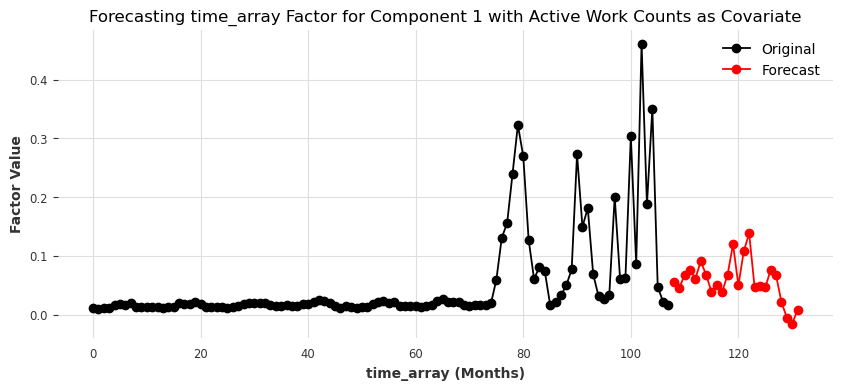


Rank 2:
Best season_length: 12


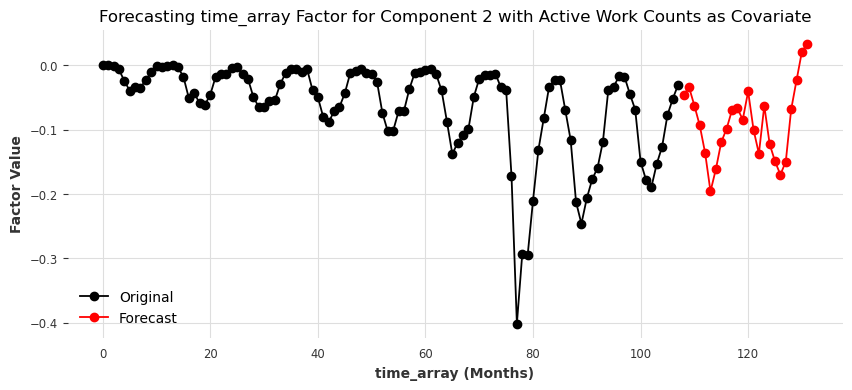


Rank 3:
Best season_length: 12


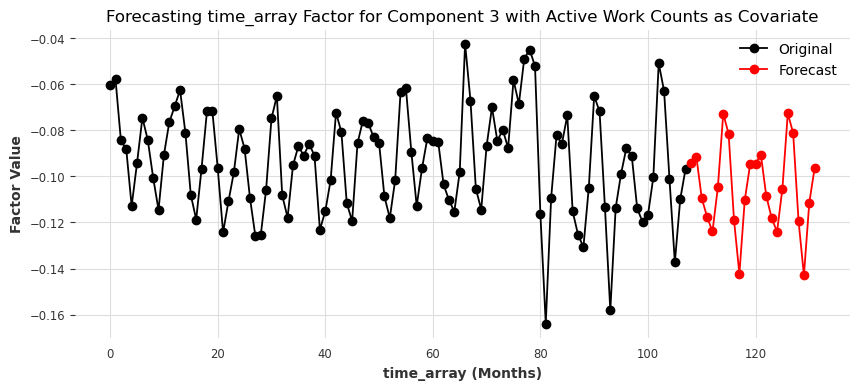


Rank 4:
Best season_length: 12


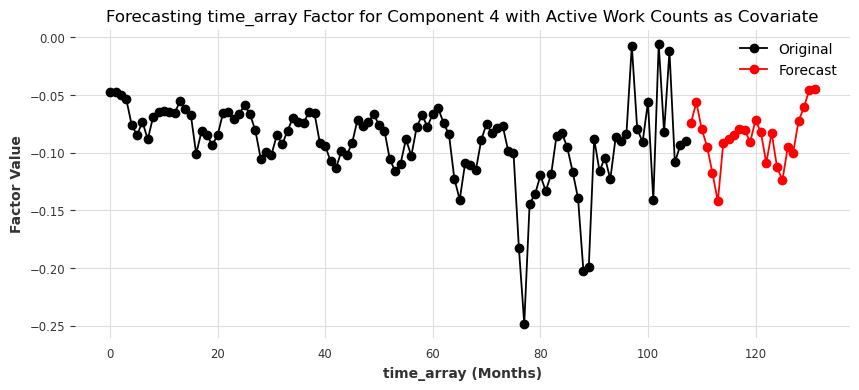

In [36]:

#############################################################
########## Dart's Gridsearch Method for AutoETS #############
#############################################################

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

factor_forecasts_average_linearfeet = []
time_index = pd.period_range(start='2014-01', end='2025-12', freq='M')
future_covariate = TimeSeries.from_times_and_values(
    time_index.to_timestamp(), 
    monthly_average_linearfeet_grouped_array.reshape(-1, 1)
)  # 2014-2025

for r in range(4):
    from darts.metrics import mse, rmse

    series = TimeSeries.from_times_and_values(
        time_index[:-36].to_timestamp(), 
        time_array[:, r].reshape(-1, 1)
    )  # 2014-2022
    
    # Grid search for best season_length using expanding window
    parameters = {'season_length': [3, 4, 6, 9, 12]}

    model = AutoETS()
    
    best_model, best_params, best_score = model.gridsearch(
        parameters=parameters,
        series=series,  # Full training data 2014-2022
        future_covariates=future_covariate[:-36],  # Covariates 2014-2022
        forecast_horizon=12,  # Predict 12 months ahead at each step
        stride=12,  # Move 12 months forward between predictions
        metric=mse  #  Use MSE for model selection
    )
    
    print(f"\nRank {r+1}:")
    print(f"Best season_length: {best_params['season_length']}")
    
    # Train final model on full data with best parameters
    final_model = AutoETS(season_length=best_params['season_length'])
    final_model.fit(series, future_covariates=future_covariate[:-36])
    
    # Predict 2023-2025
    forecast = final_model.predict(24, future_covariates=future_covariate)
    factor_forecasts_average_linearfeet.append(forecast)
    
    # Plotting
    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(len(time_array[:, r])), time_array[:, r], 
             label='Original', marker='o')
    plt.plot(np.arange(len(time_array[:, r]), len(time_array[:, r]) + 24),
             forecast.values(), label='Forecast', marker='o', color='red')
    plt.title(f'Forecasting time_array Factor for Component {r+1} with Active Work Counts as Covariate')
    plt.xlabel('time_array (Months)')
    plt.ylabel('Factor Value')
    plt.legend()
    plt.grid(True)
    plt.show()

Calculate RMSE and MSQE

In [37]:
#calculate RMSE on 2023-2024 using average linear feet adjusted forecasts, recall it's list of TimeSeries
factor_forecasts_average_linearfeet = np.array([fc.values().flatten() for fc in factor_forecasts_average_linearfeet]).T

extended_time_factor = np.vstack([time_array, factor_forecasts_average_linearfeet])
extended_factors = [tl.tensor(extended_time_factor), complaint_types, community_boards]
extended_reconstructed_tensor = cp_to_tensor((weights, extended_factors))
test_tensor = test_df.pivot_table(
    index='Year_Month', 
    columns=['Complaint Type', 'Community Board'], 
    values='count', 
    fill_value=0
).reindex(columns=pd.MultiIndex.from_product([all_complaint_types, all_community_boards], names=['Complaint Type', 'Community Board']), fill_value=0).values
test_tensor = test_tensor.reshape((test_tensor.shape[0], len(all_complaint_types), len(all_community_boards)))


estimate_time_tensor=extended_reconstructed_tensor[108:,:,:].flatten()
mse = mean_squared_error(test_tensor.flatten(), estimate_time_tensor)
rmse = np.sqrt(mse)
RMSE_dict['average_linear_feet_rmse'] = rmse
MSE_dict['average_linear_feet_mse'] = mse

print(f'Mean Squared Error on Test Set: {mse}')
print(f'Root Mean Squared Error on Test Set: {rmse}')

Mean Squared Error on Test Set: 80103.11322467965
Root Mean Squared Error on Test Set: 283.02493392752456


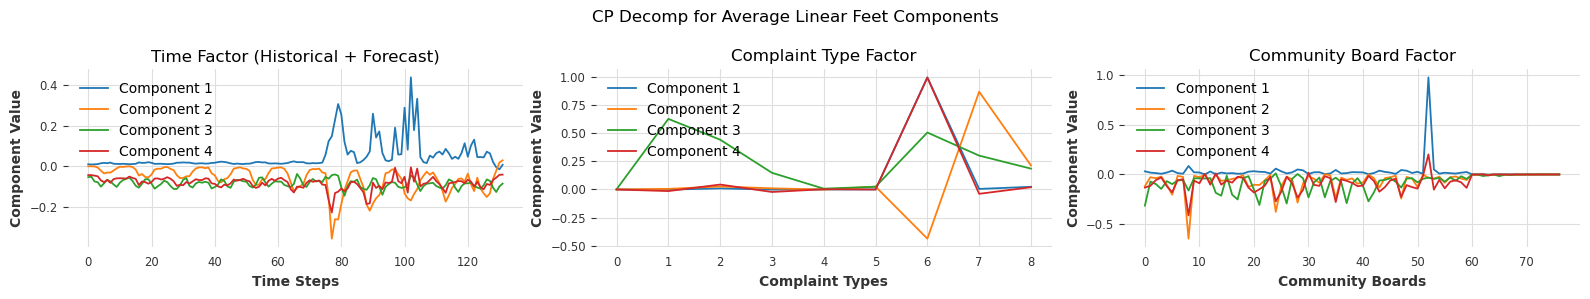

In [38]:

fig, axes = components_plot((weights, extended_factors))

axes[0].set_title("Time Factor (Historical + Forecast)")
axes[0].set_xlabel("Time Steps")
axes[0].set_ylabel("Component Value")

axes[1].set_title("Complaint Type Factor")
axes[1].set_xlabel("Complaint Types")
axes[1].set_ylabel("Component Value")

axes[2].set_title("Community Board Factor")
axes[2].set_xlabel("Community Boards")
axes[2].set_ylabel("Component Value")

fig.suptitle('CP Decomp for Average Linear Feet Components')

for ax in axes:
    lines = ax.get_lines()
    for i, line in enumerate(lines):
        line.set_color(plt.cm.tab10(i))
    ax.legend([f"Component {i+1}" for i in range(len(lines))], loc="best")

plt.tight_layout()
plt.show()

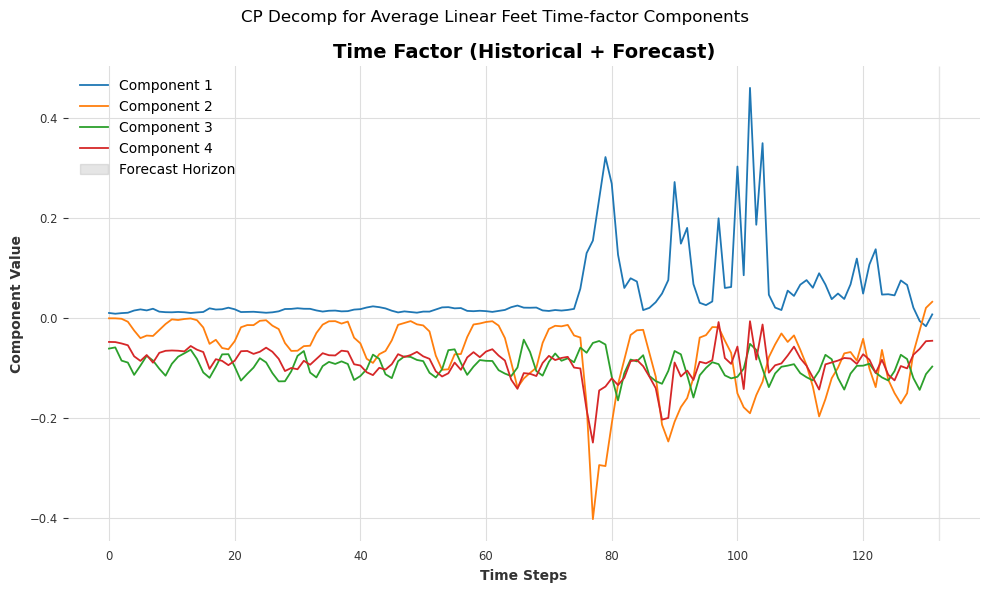

In [39]:
time_factor = extended_factors[0] 

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(time_factor.shape[1]): 
    ax.plot(range(time_factor.shape[0]), time_factor[:, i], color=plt.cm.tab10(i), label=f"Component {i+1}")

ax.set_title("Time Factor (Historical + Forecast)", fontsize=14, fontweight='bold')
ax.set_xlabel("Time Steps")
ax.set_ylabel("Component Value")

forecast_start = time_factors_full_array.shape[0]
forecast_end = extended_time_factor.shape[0]
ax.axvspan(forecast_start, forecast_end, color='gray', alpha=0.2, label="Forecast Horizon")

ax.legend(loc="best")

plt.suptitle('CP Decomp for Average Linear Feet Time-factor Components')

plt.tight_layout()
plt.show()

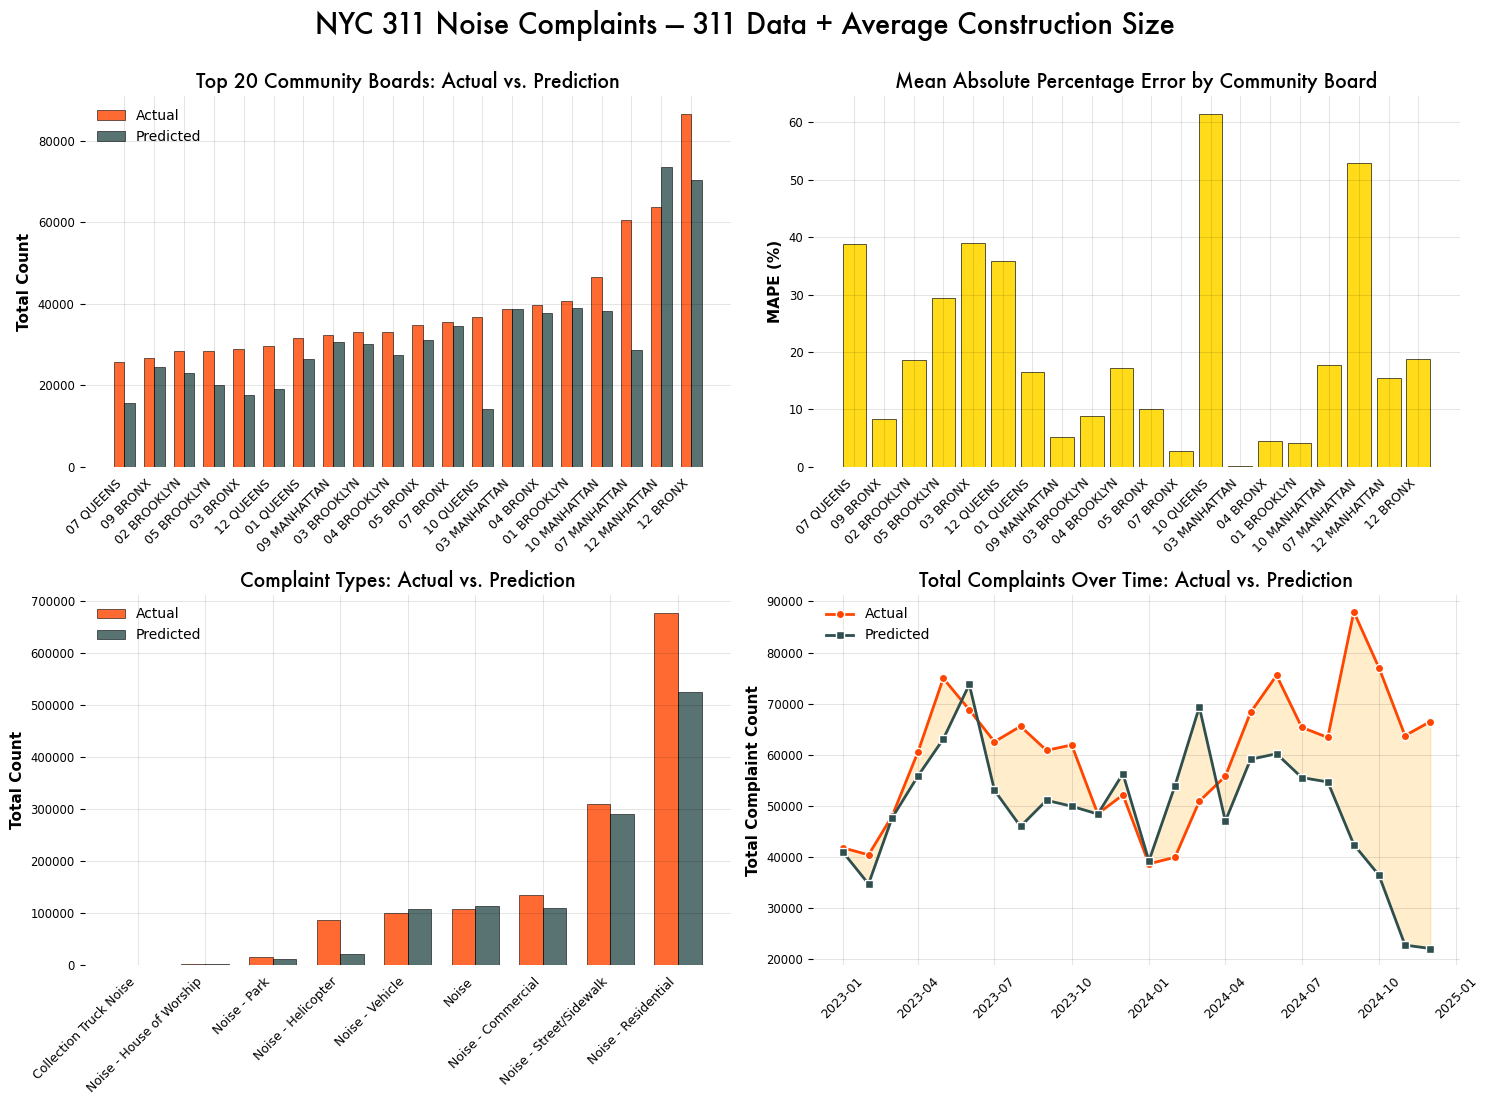

In [40]:
# Convert PyTorch tensor to NumPy at the beginning
extended_reconstructed_np = extended_reconstructed_tensor.detach().numpy()
estimate_time_tensor_np = extended_reconstructed_np[108:,:,:].flatten()

test_months = pd.date_range(start='2023-01', periods=test_tensor.shape[0], freq='MS')

# Data for Community Board plots
actual_by_board = test_tensor.sum(axis=(0, 1))
predicted_by_board = extended_reconstructed_np[108:108+test_tensor.shape[0], :, :].sum(axis=(0, 1))
mape_by_board = np.abs((actual_by_board - predicted_by_board) / 
                       (actual_by_board + 1e-10)) * 100
top_boards_idx = np.argsort(actual_by_board)[-20:]

# Data for Complaint Type plot
actual_by_complaint = test_tensor.sum(axis=(0, 2))
predicted_by_complaint = extended_reconstructed_np[108:108+test_tensor.shape[0], :, :].sum(axis=(0, 2))
top_complaints_idx = np.argsort(actual_by_complaint)[:]
top_complaints = all_complaint_types[top_complaints_idx]

# Data for Time Series plot
actual_by_time = test_tensor.sum(axis=(1, 2))
predicted_by_time = extended_reconstructed_np[108:108+test_tensor.shape[0], :, :].sum(axis=(1, 2))

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

fig.suptitle(
    "NYC 311 Noise Complaints — 311 Data + Average Construction Size",
    fontsize=20,
    fontweight='bold',
    fontfamily='Futura', 
    y=1      # adjust vertical position
)
for ax in axes.ravel():
    ax.tick_params(axis='both', colors='black')
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')

# TOP LEFT: Community Board Barchart
x_pos_board = np.arange(len(top_boards_idx))
width = 0.35
axes[0, 0].bar(x_pos_board - width/2, actual_by_board[top_boards_idx], 
               width, label='Actual', alpha=0.8, color='#FF4500', 
               edgecolor='black', linewidth=0.5)
axes[0, 0].bar(x_pos_board + width/2, predicted_by_board[top_boards_idx], 
               width, label='Predicted', alpha=0.8, color='#2F4F4F',
               edgecolor='black', linewidth=0.5)
#axes[0, 0].set_xlabel('Community Board', fontsize=11)
axes[0, 0].set_ylabel('Total Count', fontsize=11)
axes[0, 0].set_title('Top 20 Community Boards: Actual vs. Prediction', fontsize=14, fontweight='bold', fontfamily='Futura')
axes[0, 0].set_xticks(x_pos_board)
axes[0, 0].set_xticklabels(all_community_boards[top_boards_idx], rotation=45, ha='right', fontsize=9)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.1, color='black')

# TOP RIGHT: Community Board - MAPE
axes[0, 1].bar(x_pos_board, mape_by_board[top_boards_idx], alpha=0.9, color='#FFD700',
               edgecolor='black', linewidth=0.5)
#axes[0, 1].set_xlabel('Community Board', fontsize=11)
axes[0, 1].set_ylabel('MAPE (%)', fontsize=11)
axes[0, 1].set_title('Mean Absolute Percentage Error by Community Board', fontsize=14, fontweight='bold', fontfamily='Futura')
axes[0, 1].set_xticks(x_pos_board)
axes[0, 1].set_xticklabels(all_community_boards[top_boards_idx], rotation=45, ha='right', fontsize=9)
axes[0, 1].grid(True, alpha=0.1, color='black')

# BOTTOM LEFT: Complaint Type - Actual vs Predicted
x_pos_complaint = np.arange(len(top_complaints))
axes[1, 0].bar(x_pos_complaint - width/2, actual_by_complaint[top_complaints_idx], 
               width, label='Actual', alpha=0.8, color='#FF4500',
               edgecolor='black', linewidth=0.5)
axes[1, 0].bar(x_pos_complaint + width/2, predicted_by_complaint[top_complaints_idx], 
               width, label='Predicted', alpha=0.8, color='#2F4F4F',
               edgecolor='black', linewidth=0.5)
# axes[1, 0].set_xlabel('Complaint Type', fontsize=11)
axes[1, 0].set_ylabel('Total Count', fontsize=11)
axes[1, 0].set_title('Complaint Types: Actual vs. Prediction', fontsize=14, fontweight='bold', fontfamily='Futura')
axes[1, 0].set_xticks(x_pos_complaint)
axes[1, 0].set_xticklabels(top_complaints, rotation=45, ha='right', fontsize=9)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.1, color='black')

# BOTTOM RIGHT: Time Series - Actual vs Predicted Over Time
axes[1, 1].plot(test_months, actual_by_time, marker='o', label='Actual', 
                linewidth=2, markersize=6, color='#FF4500',  markeredgecolor='white')
axes[1, 1].plot(test_months, predicted_by_time, marker='s', label='Predicted', 
                linewidth=2, markersize=6, color='#2F4F4F', markeredgecolor='white')
axes[1, 1].fill_between(test_months, actual_by_time, predicted_by_time, alpha=0.2, color='#FFA500')
# axes[1, 1].set_xlabel('Month', fontsize=11)
axes[1, 1].set_ylabel('Total Complaint Count', fontsize=11)
axes[1, 1].set_title('Total Complaints Over Time: Actual vs. Prediction', fontsize=14, fontweight='bold', fontfamily='Futura')
axes[1, 1].legend(fontsize=10, loc='best')
axes[1, 1].grid(True, alpha=0.1, color='black')
axes[1, 1].tick_params(axis='x', rotation=45, labelsize=9)

plt.tight_layout()
plt.savefig('NYC311_Results_Baseline_Construction_Size.png', dpi=300, bbox_inches='tight')
plt.show()

Create a dataframe for estimates over the test period

In [41]:
T_forecast, C, B = extended_reconstructed_tensor.shape  # e.g., 144, num_complaints, num_boards

first_month = pd.to_datetime(noise_complaints_complete['Year_Month'].min())
months = pd.date_range(start=first_month, periods=T_forecast, freq='MS')

estimated_counts = extended_reconstructed_tensor.flatten()

# Repeat months for each complaint_type × board
months_flat = np.repeat(months, C * B)  # length = T*C*B

# Repeat/ tile complaints and boards to match
complaints_flat = np.tile(np.repeat(all_complaint_types, B), T_forecast)
boards_flat = np.tile(all_community_boards, T_forecast * C)

# Create DataFrame
df_estimates = pd.DataFrame({
    'Year_Month': months_flat,
    'Complaint Type': complaints_flat,
    'Community Board': boards_flat,
    'estimated_count': estimated_counts
})

In [42]:

#df_estimates.to_csv('hist_actuals_estimates_averagelinearfeet.csv')

Rebuild the tensor on all data

In [43]:
noise_complaints_complete_tensor = noise_complaints_complete.pivot_table(index='Year_Month', columns=['Complaint Type', 'Community Board'], values='count', fill_value=0).values
noise_complaints_complete_tensor = noise_complaints_complete_tensor.reshape((noise_complaints_complete_tensor.shape[0], len(all_complaint_types), len(all_community_boards)))

noise_complaints_complete_tensor=tl.tensor(noise_complaints_complete_tensor)
weights_full, factors_full = parafac(noise_complaints_complete_tensor, rank=4, normalize_factors=True)

time_factors_full, complaint_types_full, community_boards_full = factors_full

Forecast 12 months after the test period

In [44]:

#############################################################
####### use tuned Dart's AutoETS with best_params from previous grid search for forecast
#############################################################

factor_forecasts_average_linearfeet_full_array = []
time_factors_full_array=time_factors_full.detach().numpy()
time_index = pd.period_range(start='2014-01', end='2025-12', freq='M')
future_covariate= TimeSeries.from_times_and_values(time_index.to_timestamp(), monthly_average_linearfeet_grouped_array.reshape(-1,1)) #2012-2025

for r in range(4):
    model = AutoETS(season_length=best_params['season_length'])

    series = TimeSeries.from_times_and_values(
        time_index[:-12].to_timestamp(), 
        time_factors_full_array[:, r].reshape(-1,1)
        ) #2014-2022
    model.fit(series, future_covariates = future_covariate[:-12]) #Future covariates up to end of 2024
    forecast = model.predict(12, future_covariates = future_covariate) #predict 2025, provide future covariates
    factor_forecasts_average_linearfeet_full_array.append(forecast)







Fold Back into tensor and create predictions

In [45]:
factor_forecasts_average_linearfeet_full_array = np.array([fc.values().flatten() for fc in factor_forecasts_average_linearfeet_full_array]).T
extended_time_factor = np.vstack([time_factors_full_array, factor_forecasts_average_linearfeet_full_array])
extended_factors = [tl.tensor(extended_time_factor), complaint_types_full, community_boards_full]
extended_reconstructed_tensor = cp_to_tensor((weights_full, extended_factors))


T_forecast, C, B = extended_reconstructed_tensor.shape 
predicted_counts = extended_reconstructed_tensor[-12:,:,:].flatten()
last_month = pd.to_datetime(noise_complaints_complete['Year_Month'].max())
months = pd.date_range(start=last_month + pd.offsets.MonthBegin(), periods=12, freq='MS')
df_forecast_average_linearfeet = pd.DataFrame({
    'Year_Month': np.repeat(months, C * B),
    'Complaint Type': np.tile(np.repeat(all_complaint_types, B), 12),
    'Community Board': np.tile(all_community_boards, 12 * C),
    'predicted_count': predicted_counts
})

In [46]:
#df_forecast_average_linearfeet.to_csv('forecasts_averagelinearfeet.csv')

# 5. Baseline 311 + Event Counts

To obtain event_permit_full_date_only.csv, 

- The user must query the data at the following link: https://data.cityofnewyork.us/City-Government/NYC-Permitted-Event-Information-Historical/bkfu-528j/explore

- Once here, the user must apply the following filters before downlading data to a csv:
    - Filter 'Start Date/Time' to BETWEEN '2014 Jan 01 12:00:00 AM' and '2024 Dec 31 11:59:59 PM'

- Once filtered, the user will save the dataset to the 'data' folder and name it as 'event_permit_full_date_only.csv'


Lastly repeat for event permit

In [47]:
event_permit_df=pd.read_csv('data/event_permit_full_date_only.csv')

Group the data

In [48]:
#count of events by year_month
#confirm event_count for all year_month between 2014-2025

monthly_event_permit_grouped_array=event_permit_df.groupby('Year_Month').size().sort_index().values

In [49]:
monthly_event_permit_grouped_2025_array=monthly_event_permit_grouped_array[-12:] #get 2025
monthly_event_permit_grouped_2012_2024=monthly_event_permit_grouped_array[:-12] #remove 2025

Use Auto ETS and forecast 24 months out 


Rank 1:
Best season_length: 12


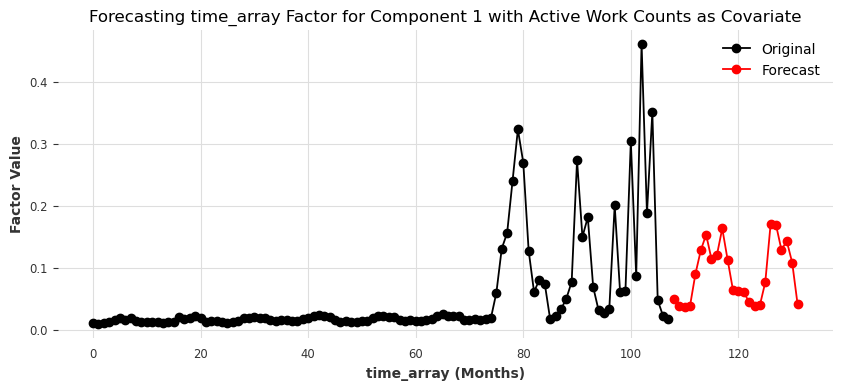


Rank 2:
Best season_length: 12


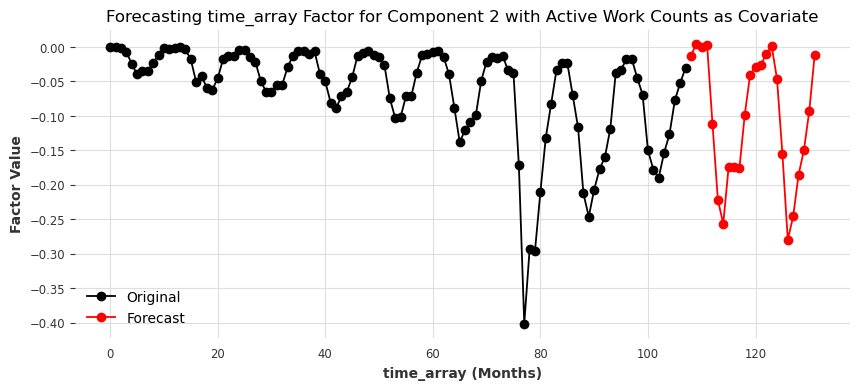


Rank 3:
Best season_length: 12


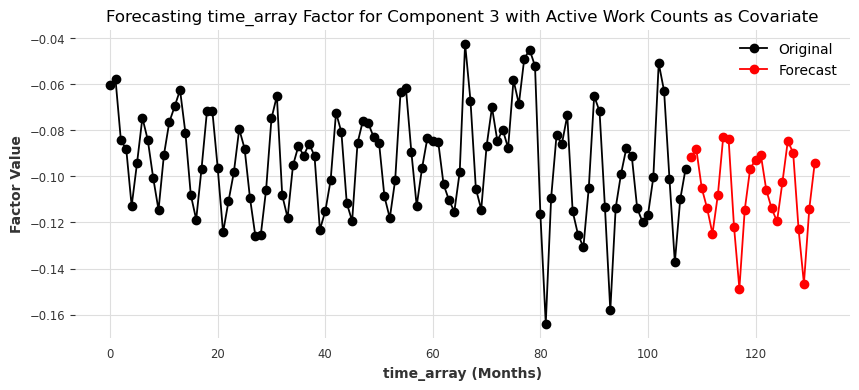


Rank 4:
Best season_length: 4


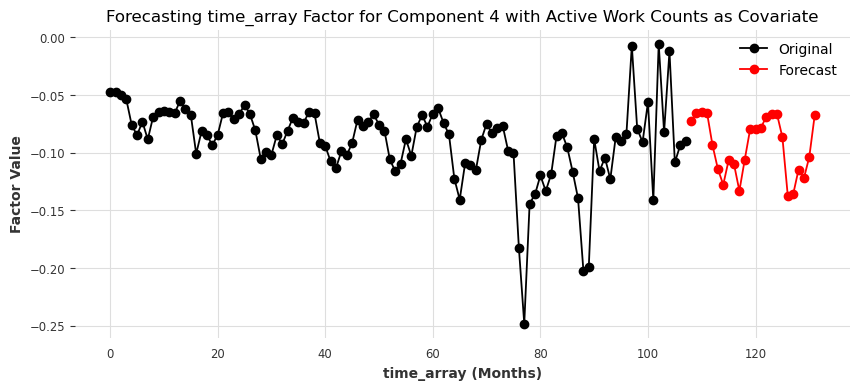

In [50]:

#############################################################
########## Dart's Gridsearch Method for AutoETS #############
#############################################################

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

factor_forecasts_event_permit = []
time_index = pd.period_range(start='2014-01', end='2025-12', freq='M')
future_covariate= TimeSeries.from_times_and_values(
    time_index.to_timestamp(), 
    monthly_event_permit_grouped_array.reshape(-1,1)
    ) #2012-2025

for r in range(4):
    from darts.metrics import mse, rmse

    series = TimeSeries.from_times_and_values(
        time_index[:-36].to_timestamp(), 
        time_array[:, r].reshape(-1, 1)
    )  # 2014-2022
    
    # Grid search for best season_length using expanding window
    parameters = {'season_length': [3, 4, 6, 9, 12]}

    model = AutoETS()
    
    best_model, best_params, best_score = model.gridsearch(
        parameters=parameters,
        series=series,  # Full training data 2014-2022
        future_covariates=future_covariate[:-36],  # Covariates 2014-2022
        forecast_horizon=12,  # Predict 12 months ahead at each step
        stride=12,  # Move 12 months forward between predictions
        metric=mse  #  Use MSE for model selection
    )
    
    print(f"\nRank {r+1}:")
    print(f"Best season_length: {best_params['season_length']}")
    
    # Train final model on full data with best parameters
    final_model = AutoETS(season_length=best_params['season_length'])
    final_model.fit(series, future_covariates=future_covariate[:-36])
    
    # Predict 2023-2025
    forecast = final_model.predict(24, future_covariates=future_covariate)
    factor_forecasts_event_permit.append(forecast)
    
    # Plotting
    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(len(time_array[:, r])), time_array[:, r], 
             label='Original', marker='o')
    plt.plot(np.arange(len(time_array[:, r]), len(time_array[:, r]) + 24),
             forecast.values(), label='Forecast', marker='o', color='red')
    plt.title(f'Forecasting time_array Factor for Component {r+1} with Active Work Counts as Covariate')
    plt.xlabel('time_array (Months)')
    plt.ylabel('Factor Value')
    plt.legend()
    plt.grid(True)
    plt.show()

Calculate RMSE and MSQE

In [51]:
#calculate RMSE on 2023-2024 using event permit adjusted forecasts, recall it's list of TimeSeries
factor_forecasts_event_permit = np.array([fc.values().flatten() for fc in factor_forecasts_event_permit]).T

extended_time_factor = np.vstack([time_array, factor_forecasts_event_permit])
extended_factors = [tl.tensor(extended_time_factor), complaint_types, community_boards]
extended_reconstructed_tensor = cp_to_tensor((weights, extended_factors))
test_tensor = test_df.pivot_table(
    index='Year_Month', 
    columns=['Complaint Type', 'Community Board'], 
    values='count', 
    fill_value=0
).reindex(columns=pd.MultiIndex.from_product([all_complaint_types, all_community_boards], names=['Complaint Type', 'Community Board']), fill_value=0).values
test_tensor = test_tensor.reshape((test_tensor.shape[0], len(all_complaint_types), len(all_community_boards)))


estimate_time_tensor=extended_reconstructed_tensor[108:,:,:].flatten()
mse = mean_squared_error(test_tensor.flatten(), estimate_time_tensor)
rmse = np.sqrt(mse)
RMSE_dict['event_permit_rmse'] = rmse
MSE_dict['event_permit_mse'] = mse

print(f'Mean Squared Error on Test Set: {mse}')
print(f'Root Mean Squared Error on Test Set: {rmse}')

Mean Squared Error on Test Set: 64453.63223788698
Root Mean Squared Error on Test Set: 253.87719912959292


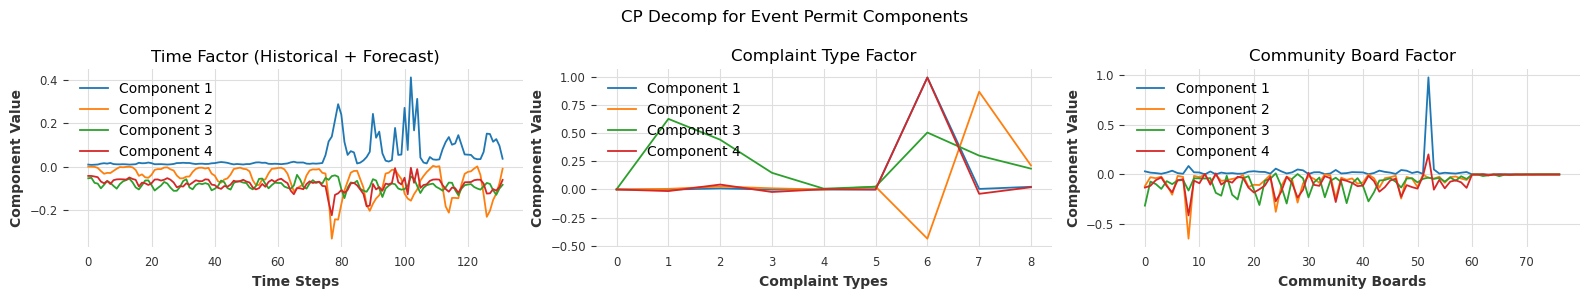

In [52]:

fig, axes = components_plot((weights, extended_factors))

axes[0].set_title("Time Factor (Historical + Forecast)")
axes[0].set_xlabel("Time Steps")
axes[0].set_ylabel("Component Value")

axes[1].set_title("Complaint Type Factor")
axes[1].set_xlabel("Complaint Types")
axes[1].set_ylabel("Component Value")

axes[2].set_title("Community Board Factor")
axes[2].set_xlabel("Community Boards")
axes[2].set_ylabel("Component Value")

fig.suptitle('CP Decomp for Event Permit Components')

for ax in axes:
    lines = ax.get_lines()
    for i, line in enumerate(lines):
        line.set_color(plt.cm.tab10(i))
    ax.legend([f"Component {i+1}" for i in range(len(lines))], loc="best")

plt.tight_layout()
plt.show()

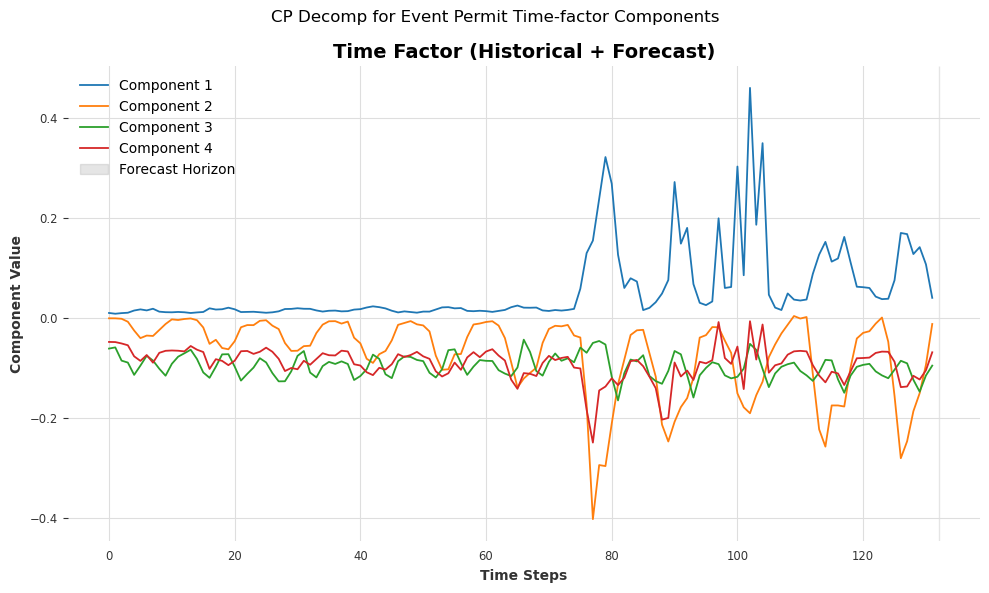

In [53]:
time_factor = extended_factors[0] 

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(time_factor.shape[1]): 
    ax.plot(range(time_factor.shape[0]), time_factor[:, i], color=plt.cm.tab10(i), label=f"Component {i+1}")

ax.set_title("Time Factor (Historical + Forecast)", fontsize=14, fontweight='bold')
ax.set_xlabel("Time Steps")
ax.set_ylabel("Component Value")

forecast_start = time_factors_full_array.shape[0]
forecast_end = extended_time_factor.shape[0]
ax.axvspan(forecast_start, forecast_end, color='gray', alpha=0.2, label="Forecast Horizon")

ax.legend(loc="best")

plt.suptitle('CP Decomp for Event Permit Time-factor Components')

plt.tight_layout()
plt.show()

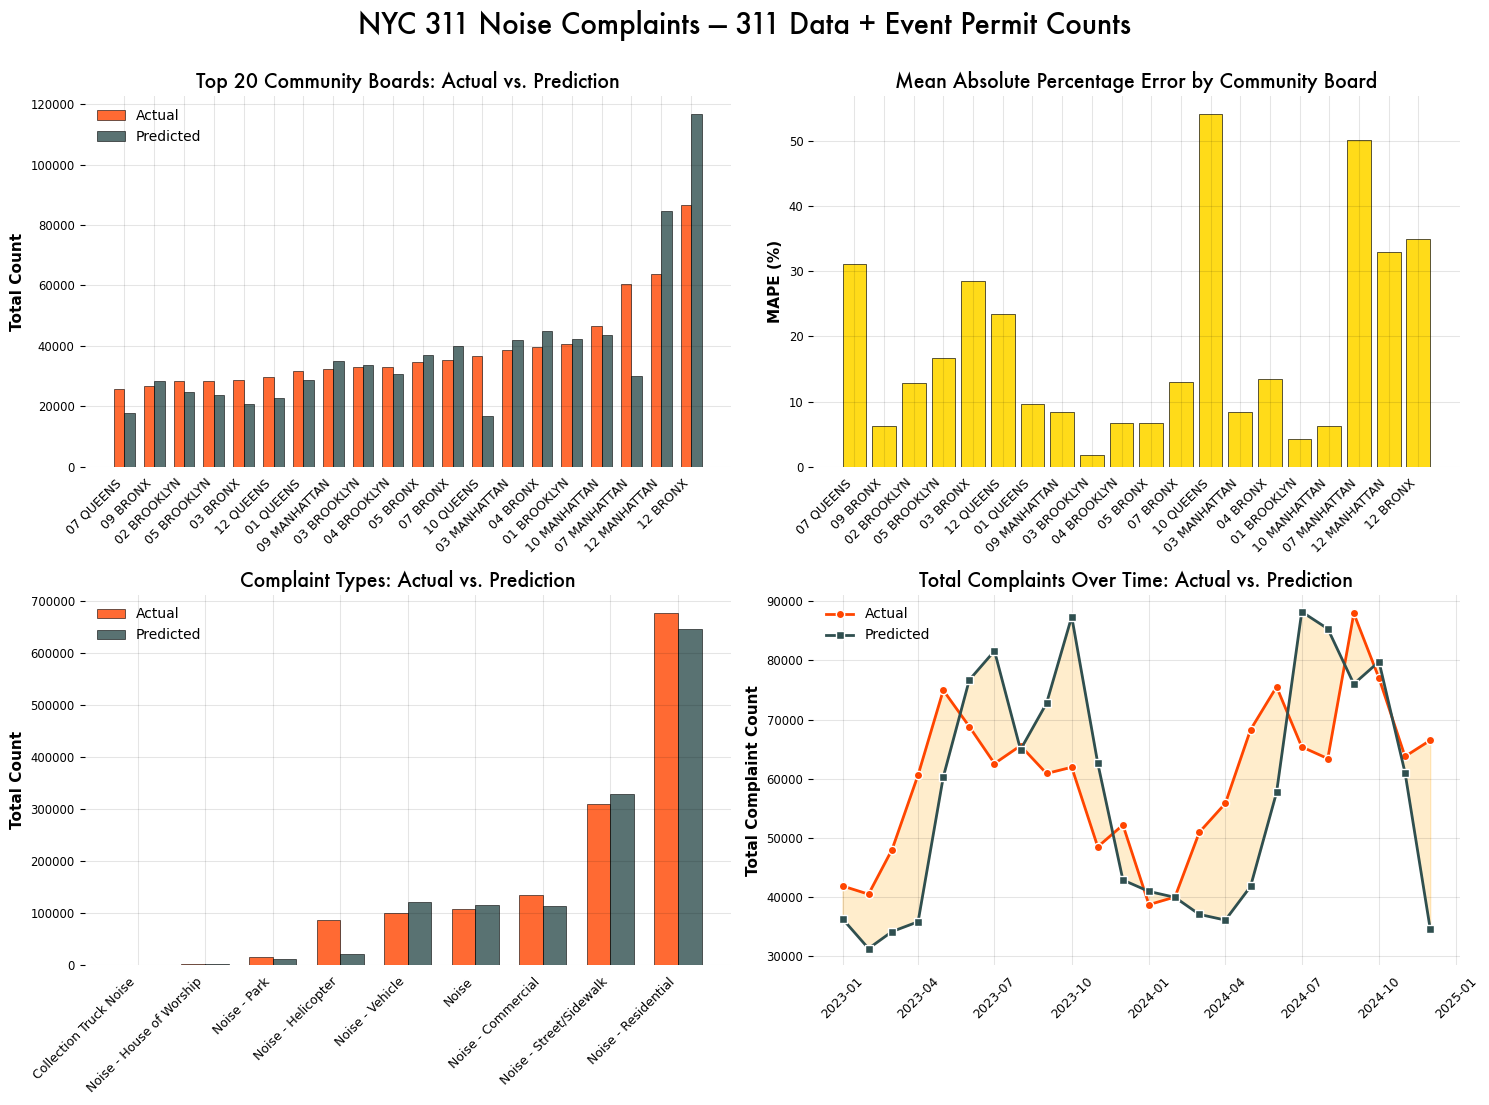

In [54]:
# Convert PyTorch tensor to NumPy at the beginning
extended_reconstructed_np = extended_reconstructed_tensor.detach().numpy()
estimate_time_tensor_np = extended_reconstructed_np[108:,:,:].flatten()

test_months = pd.date_range(start='2023-01', periods=test_tensor.shape[0], freq='MS')

# Data for Community Board plots
actual_by_board = test_tensor.sum(axis=(0, 1))
predicted_by_board = extended_reconstructed_np[108:108+test_tensor.shape[0], :, :].sum(axis=(0, 1))
mape_by_board = np.abs((actual_by_board - predicted_by_board) / 
                       (actual_by_board + 1e-10)) * 100
top_boards_idx = np.argsort(actual_by_board)[-20:]

# Data for Complaint Type plot
actual_by_complaint = test_tensor.sum(axis=(0, 2))
predicted_by_complaint = extended_reconstructed_np[108:108+test_tensor.shape[0], :, :].sum(axis=(0, 2))
top_complaints_idx = np.argsort(actual_by_complaint)[:]
top_complaints = all_complaint_types[top_complaints_idx]

# Data for Time Series plot
actual_by_time = test_tensor.sum(axis=(1, 2))
predicted_by_time = extended_reconstructed_np[108:108+test_tensor.shape[0], :, :].sum(axis=(1, 2))

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

fig.suptitle(
    "NYC 311 Noise Complaints — 311 Data + Event Permit Counts",
    fontsize=20,
    fontweight='bold',
    fontfamily='Futura', 
    y=1      # adjust vertical position
)
for ax in axes.ravel():
    ax.tick_params(axis='both', colors='black')
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')

# TOP LEFT: Community Board Barchart
x_pos_board = np.arange(len(top_boards_idx))
width = 0.35
axes[0, 0].bar(x_pos_board - width/2, actual_by_board[top_boards_idx], 
               width, label='Actual', alpha=0.8, color='#FF4500', 
               edgecolor='black', linewidth=0.5)
axes[0, 0].bar(x_pos_board + width/2, predicted_by_board[top_boards_idx], 
               width, label='Predicted', alpha=0.8, color='#2F4F4F',
               edgecolor='black', linewidth=0.5)
#axes[0, 0].set_xlabel('Community Board', fontsize=11)
axes[0, 0].set_ylabel('Total Count', fontsize=11)
axes[0, 0].set_title('Top 20 Community Boards: Actual vs. Prediction', fontsize=14, fontweight='bold', fontfamily='Futura')
axes[0, 0].set_xticks(x_pos_board)
axes[0, 0].set_xticklabels(all_community_boards[top_boards_idx], rotation=45, ha='right', fontsize=9)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.1, color='black')

# TOP RIGHT: Community Board - MAPE
axes[0, 1].bar(x_pos_board, mape_by_board[top_boards_idx], alpha=0.9, color='#FFD700',
               edgecolor='black', linewidth=0.5)
#axes[0, 1].set_xlabel('Community Board', fontsize=11)
axes[0, 1].set_ylabel('MAPE (%)', fontsize=11)
axes[0, 1].set_title('Mean Absolute Percentage Error by Community Board', fontsize=14, fontweight='bold', fontfamily='Futura')
axes[0, 1].set_xticks(x_pos_board)
axes[0, 1].set_xticklabels(all_community_boards[top_boards_idx], rotation=45, ha='right', fontsize=9)
axes[0, 1].grid(True, alpha=0.1, color='black')

# BOTTOM LEFT: Complaint Type - Actual vs Predicted
x_pos_complaint = np.arange(len(top_complaints))
axes[1, 0].bar(x_pos_complaint - width/2, actual_by_complaint[top_complaints_idx], 
               width, label='Actual', alpha=0.8, color='#FF4500',
               edgecolor='black', linewidth=0.5)
axes[1, 0].bar(x_pos_complaint + width/2, predicted_by_complaint[top_complaints_idx], 
               width, label='Predicted', alpha=0.8, color='#2F4F4F',
               edgecolor='black', linewidth=0.5)
# axes[1, 0].set_xlabel('Complaint Type', fontsize=11)
axes[1, 0].set_ylabel('Total Count', fontsize=11)
axes[1, 0].set_title('Complaint Types: Actual vs. Prediction', fontsize=14, fontweight='bold', fontfamily='Futura')
axes[1, 0].set_xticks(x_pos_complaint)
axes[1, 0].set_xticklabels(top_complaints, rotation=45, ha='right', fontsize=9)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.1, color='black')

# BOTTOM RIGHT: Time Series - Actual vs Predicted Over Time
axes[1, 1].plot(test_months, actual_by_time, marker='o', label='Actual', 
                linewidth=2, markersize=6, color='#FF4500',  markeredgecolor='white')
axes[1, 1].plot(test_months, predicted_by_time, marker='s', label='Predicted', 
                linewidth=2, markersize=6, color='#2F4F4F', markeredgecolor='white')
axes[1, 1].fill_between(test_months, actual_by_time, predicted_by_time, alpha=0.2, color='#FFA500')
# axes[1, 1].set_xlabel('Month', fontsize=11)
axes[1, 1].set_ylabel('Total Complaint Count', fontsize=11)
axes[1, 1].set_title('Total Complaints Over Time: Actual vs. Prediction', fontsize=14, fontweight='bold', fontfamily='Futura')
axes[1, 1].legend(fontsize=10, loc='best')
axes[1, 1].grid(True, alpha=0.1, color='black')
axes[1, 1].tick_params(axis='x', rotation=45, labelsize=9)

plt.tight_layout()
plt.savefig('NYC311_Results_Baseline_Event_Count.png', dpi=300, bbox_inches='tight')
plt.show()

Create a dataframe for estimates over the test period

In [55]:
T_forecast, C, B = extended_reconstructed_tensor.shape  # e.g., 144, num_complaints, num_boards

first_month = pd.to_datetime(noise_complaints_complete['Year_Month'].min())
months = pd.date_range(start=first_month, periods=T_forecast, freq='MS')

estimated_counts = extended_reconstructed_tensor.flatten()

# Repeat months for each complaint_type × board
months_flat = np.repeat(months, C * B)  # length = T*C*B

# Repeat/ tile complaints and boards to match
complaints_flat = np.tile(np.repeat(all_complaint_types, B), T_forecast)
boards_flat = np.tile(all_community_boards, T_forecast * C)

# Create DataFrame
df_estimates = pd.DataFrame({
    'Year_Month': months_flat,
    'Complaint Type': complaints_flat,
    'Community Board': boards_flat,
    'estimated_count': estimated_counts
})

In [56]:
#df_estimates.to_csv('hist_actuals_estimates_eventpermit.csv')

Rebuild Tensor on all data

In [57]:
noise_complaints_complete_tensor = noise_complaints_complete.pivot_table(index='Year_Month', columns=['Complaint Type', 'Community Board'], values='count', fill_value=0).values
noise_complaints_complete_tensor = noise_complaints_complete_tensor.reshape((noise_complaints_complete_tensor.shape[0], len(all_complaint_types), len(all_community_boards)))

noise_complaints_complete_tensor=tl.tensor(noise_complaints_complete_tensor)
weights_full, factors_full = parafac(noise_complaints_complete_tensor, rank=4, normalize_factors=True)

time_factors_full, complaint_types_full, community_boards_full = factors_full

Forecast 12 months after test period

In [58]:
#############################################################
####### use tuned Dart's AutoETS with best_params from previous grid search for forecast
#############################################################

factor_forecasts_event_permit_full_array = []
time_factors_full_array=time_factors_full.detach().numpy()
time_index = pd.period_range(start='2014-01', end='2025-12', freq='M')
future_covariate= TimeSeries.from_times_and_values(
    time_index.to_timestamp(), 
    monthly_event_permit_grouped_array.reshape(-1,1)
    ) #2012-2025

for r in range(4):
    series = TimeSeries.from_times_and_values(
        time_index[:-12].to_timestamp(), 
        time_factors_full_array[:, r].reshape(-1,1)
    )  # 2014-2022

    model = AutoETS(season_length=best_params['season_length'])
    
    model.fit(series, future_covariates = future_covariate[:-12]) #Future covariates up to end of 2024
    forecast = model.predict(12, future_covariates = future_covariate) #predict 2025, provide future covariates
    factor_forecasts_event_permit_full_array.append(forecast)

Fold back into tensor and create predictions

In [59]:
factor_forecasts_event_permit_full_array = np.array([fc.values().flatten() for fc in factor_forecasts_event_permit_full_array]).T
extended_time_factor = np.vstack([time_factors_full_array, factor_forecasts_event_permit_full_array])
extended_factors = [tl.tensor(extended_time_factor), complaint_types_full, community_boards_full]
extended_reconstructed_tensor = cp_to_tensor((weights_full, extended_factors))


T_forecast, C, B = extended_reconstructed_tensor.shape 
predicted_counts = extended_reconstructed_tensor[-12:,:,:].flatten()
last_month = pd.to_datetime(noise_complaints_complete['Year_Month'].max())
months = pd.date_range(start=last_month + pd.offsets.MonthBegin(), periods=12, freq='MS')
df_forecast_event_permit = pd.DataFrame({
    'Year_Month': np.repeat(months, C * B),
    'Complaint Type': np.tile(np.repeat(all_complaint_types, B), 12),
    'Community Board': np.tile(all_community_boards, 12 * C),
    'predicted_count': predicted_counts
})

In [60]:
#df_forecast_event_permit.to_csv('forecasts_eventpermit.csv')

# 6. Combine all three covariates (construction count, linear footage, and event count)


Rank 1:
Best season_length: 12


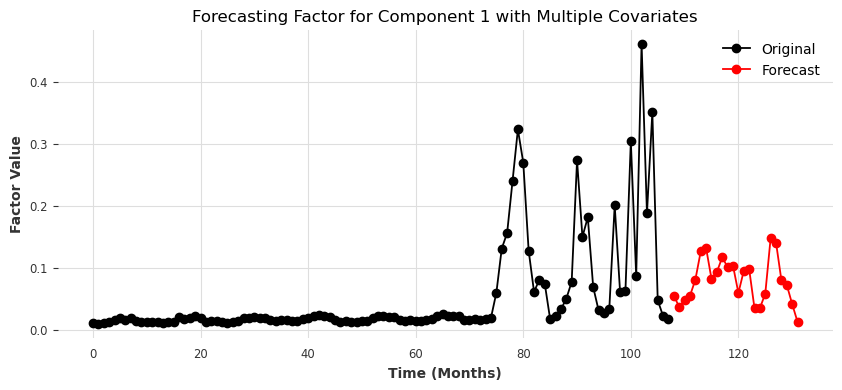


Rank 2:
Best season_length: 12


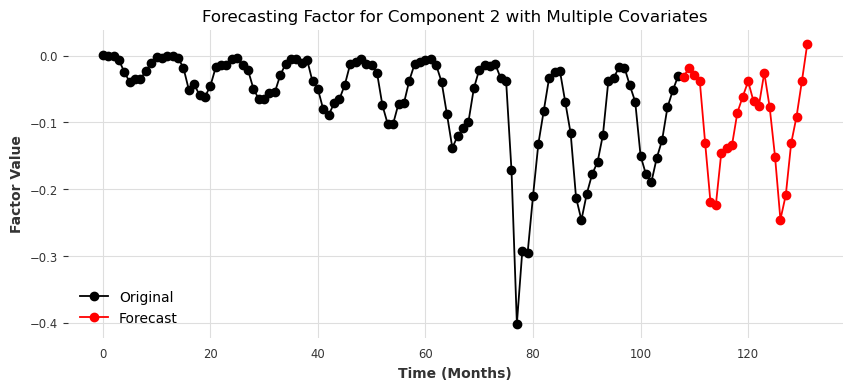


Rank 3:
Best season_length: 12


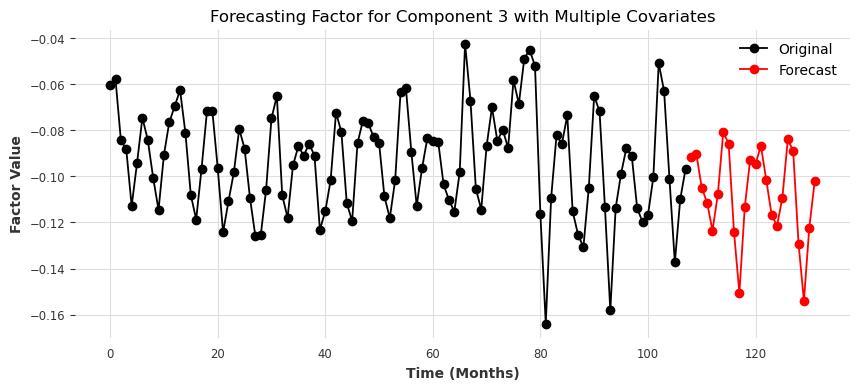


Rank 4:
Best season_length: 4


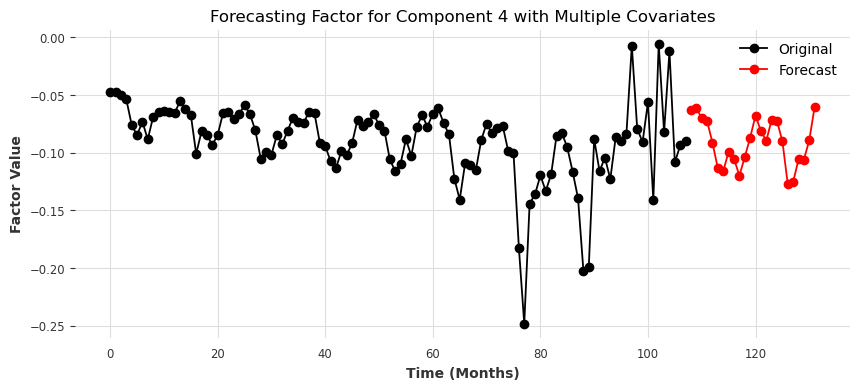

In [61]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
from darts.metrics import mse, rmse

factor_forecasts_multi_covariates = []
time_index = pd.period_range(start='2014-01', end='2025-12', freq='M')

# Combine all three covariates into a single multivariate TimeSeries
# Stack them as columns (axis=1)
combined_covariates = np.column_stack([
    monthly_event_permit_grouped_array,
    monthly_active_work_counts_grouped_array,
    monthly_average_linearfeet_grouped_array
])

future_covariate = TimeSeries.from_times_and_values(
    time_index.to_timestamp(), 
    combined_covariates  # Shape: (144, 3) - 3 covariates
)  # 2014-2025

for r in range(4):
    series = TimeSeries.from_times_and_values(
        time_index[:-36].to_timestamp(), 
        time_array[:, r].reshape(-1, 1)
    )  # 2014-2022
    
    # Grid search for best season_length using expanding window
    parameters = {'season_length': [3, 4, 6, 9, 12]}

    model = AutoETS()
    
    best_model, best_params, best_score = model.gridsearch(
        parameters=parameters,
        series=series,  # Full training data 2014-2022
        future_covariates=future_covariate[:-36],  # All 3 covariates 2014-2022
        forecast_horizon=12,  # Predict 12 months ahead at each step
        stride=12,  # Move 12 months forward between predictions
        metric=mse,  # Use MSE for model selection
        show_warnings=False
    )
    
    print(f"\nRank {r+1}:")
    print(f"Best season_length: {best_params['season_length']}")
    
    # Train final model on full data with best parameters
    final_model = AutoETS(season_length=best_params['season_length'])
    final_model.fit(series, future_covariates=future_covariate[:-36])
    
    # Predict 2023-2025 (provide all future covariates for forecast period)
    forecast = final_model.predict(24, future_covariates=future_covariate)
    factor_forecasts_multi_covariates.append(forecast)
    
    # Plotting
    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(len(time_array[:, r])), time_array[:, r], 
             label='Original', marker='o')
    plt.plot(np.arange(len(time_array[:, r]), len(time_array[:, r]) + 24),
             forecast.values().flatten(), label='Forecast', marker='o', color='red')
    plt.title(f'Forecasting Factor for Component {r+1} with Multiple Covariates')
    plt.xlabel('Time (Months)')
    plt.ylabel('Factor Value')
    plt.legend()
    plt.grid(True)
    plt.show()



In [62]:
# Convert to numpy array
factor_forecasts_multi_covariates = np.array([fc.values().flatten() for fc in factor_forecasts_multi_covariates]).T

extended_time_factor = np.vstack([time_array, factor_forecasts_multi_covariates])
extended_factors = [tl.tensor(extended_time_factor), complaint_types, community_boards]
extended_reconstructed_tensor = cp_to_tensor((weights, extended_factors))
test_tensor = test_df.pivot_table(
    index='Year_Month', 
    columns=['Complaint Type', 'Community Board'], 
    values='count', 
    fill_value=0
).reindex(columns=pd.MultiIndex.from_product([all_complaint_types, all_community_boards], names=['Complaint Type', 'Community Board']), fill_value=0).values
test_tensor = test_tensor.reshape((test_tensor.shape[0], len(all_complaint_types), len(all_community_boards)))


estimate_time_tensor=extended_reconstructed_tensor[108:,:,:].flatten()
mse = mean_squared_error(test_tensor.flatten(), estimate_time_tensor)
rmse = np.sqrt(mse)
RMSE_dict['composite_rmse']= rmse
MSE_dict['composite_mse'] = mse

print(f'Mean Squared Error on Test Set: {mse}')
print(f'Root Mean Squared Error on Test Set: {rmse}')

Mean Squared Error on Test Set: 71995.49306186517
Root Mean Squared Error on Test Set: 268.31975898518016


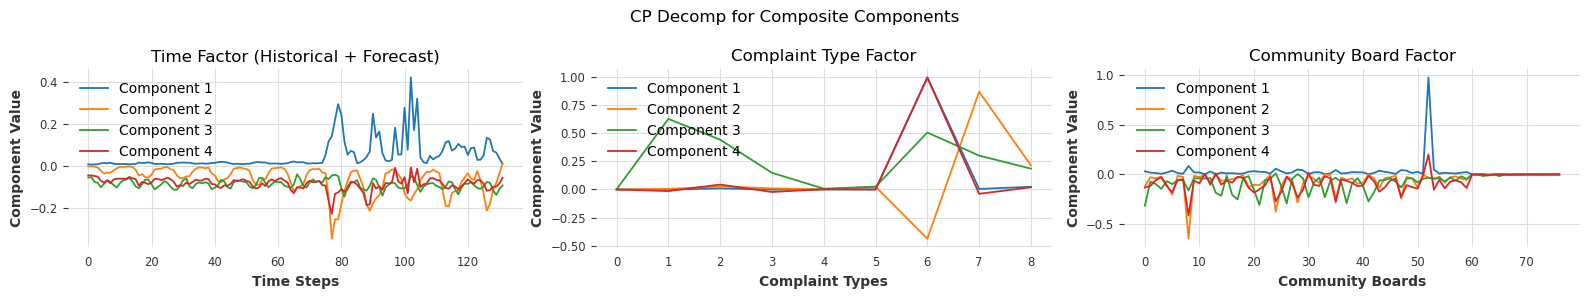

In [63]:

fig, axes = components_plot((weights, extended_factors))

axes[0].set_title("Time Factor (Historical + Forecast)")
axes[0].set_xlabel("Time Steps")
axes[0].set_ylabel("Component Value")

axes[1].set_title("Complaint Type Factor")
axes[1].set_xlabel("Complaint Types")
axes[1].set_ylabel("Component Value")

axes[2].set_title("Community Board Factor")
axes[2].set_xlabel("Community Boards")
axes[2].set_ylabel("Component Value")

fig.suptitle('CP Decomp for Composite Components')

for ax in axes:
    lines = ax.get_lines()
    for i, line in enumerate(lines):
        line.set_color(plt.cm.tab10(i))
    ax.legend([f"Component {i+1}" for i in range(len(lines))], loc="best")

plt.tight_layout()
plt.show()

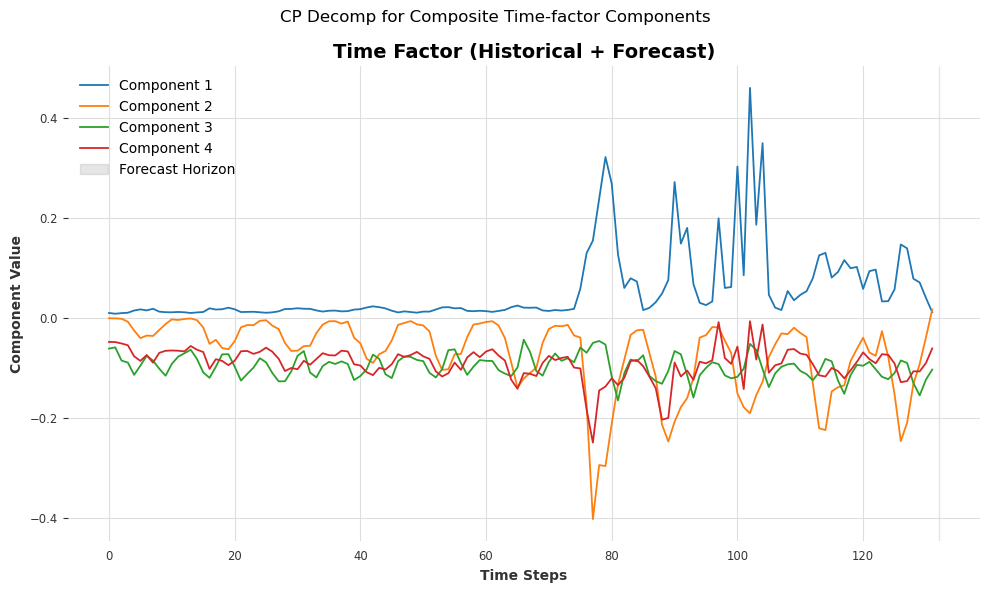

In [64]:

time_factor = extended_factors[0] 

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(time_factor.shape[1]): 
    ax.plot(range(time_factor.shape[0]), time_factor[:, i], color=plt.cm.tab10(i), label=f"Component {i+1}")

ax.set_title("Time Factor (Historical + Forecast)", fontsize=14, fontweight='bold')
ax.set_xlabel("Time Steps")
ax.set_ylabel("Component Value")

forecast_start = time_factors_full_array.shape[0]
forecast_end = extended_time_factor.shape[0]
ax.axvspan(forecast_start, forecast_end, color='gray', alpha=0.2, label="Forecast Horizon")

ax.legend(loc="best")

plt.suptitle('CP Decomp for Composite Time-factor Components')

plt.tight_layout()
plt.show()

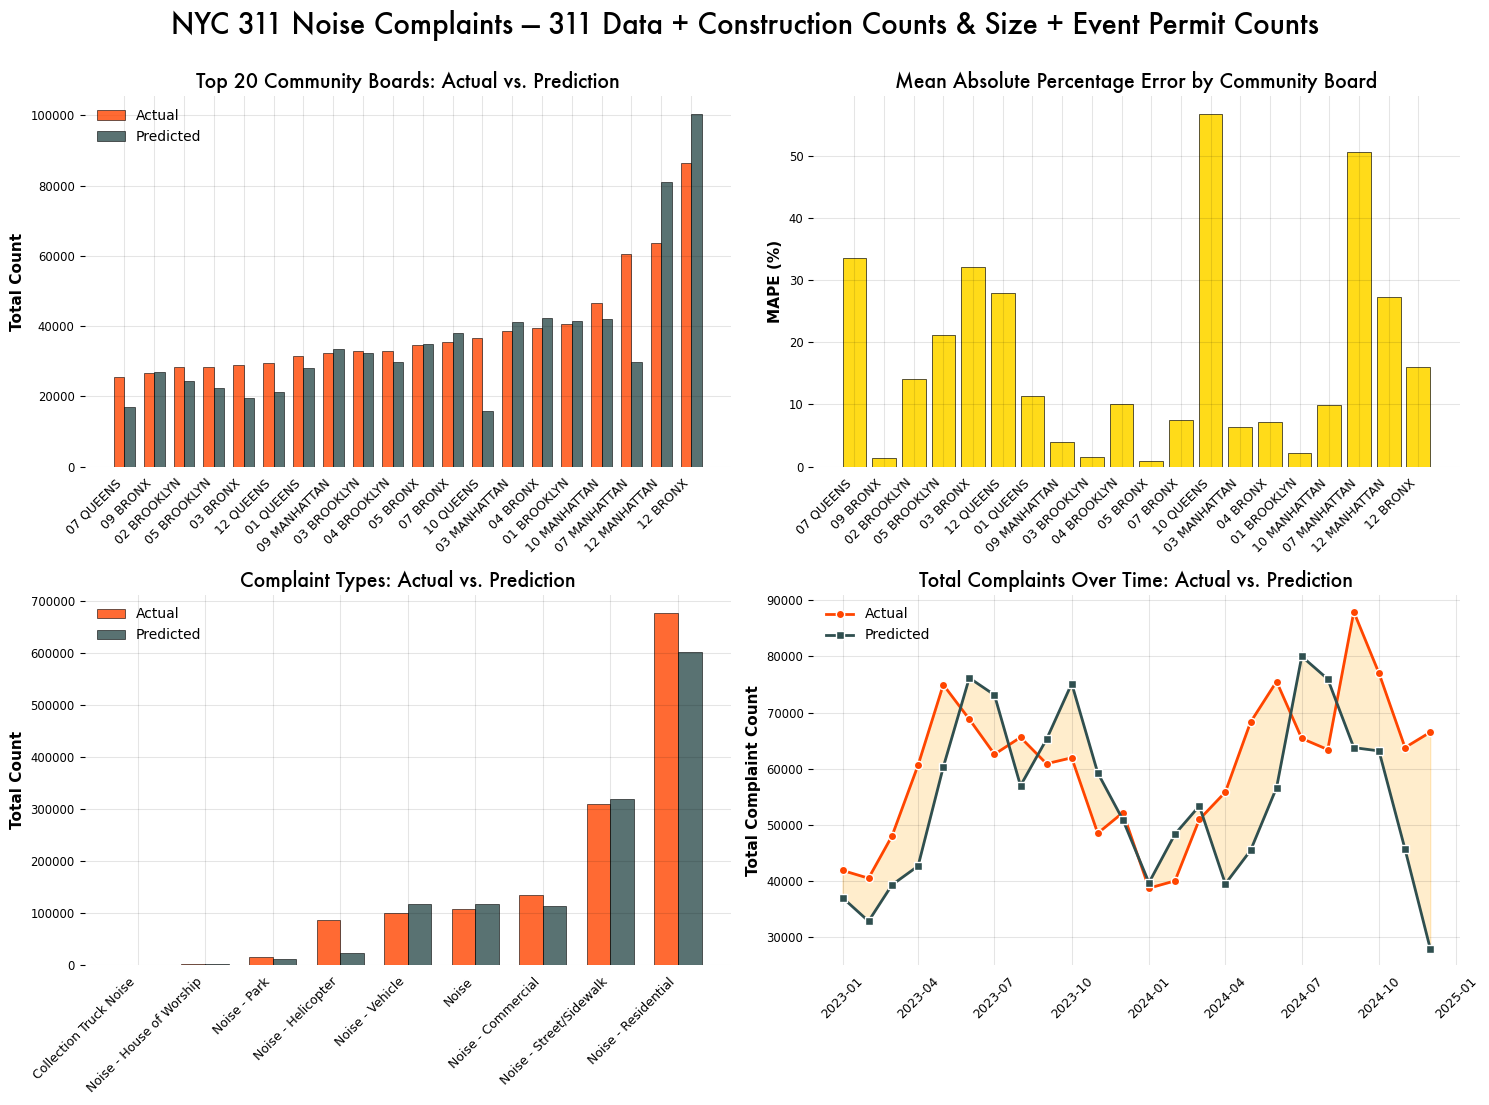

In [65]:
# Convert PyTorch tensor to NumPy at the beginning
extended_reconstructed_np = extended_reconstructed_tensor.detach().numpy()
estimate_time_tensor_np = extended_reconstructed_np[108:,:,:].flatten()

test_months = pd.date_range(start='2023-01', periods=test_tensor.shape[0], freq='MS')

# Data for Community Board plots
actual_by_board = test_tensor.sum(axis=(0, 1))
predicted_by_board = extended_reconstructed_np[108:108+test_tensor.shape[0], :, :].sum(axis=(0, 1))
mape_by_board = np.abs((actual_by_board - predicted_by_board) / 
                       (actual_by_board + 1e-10)) * 100
top_boards_idx = np.argsort(actual_by_board)[-20:]

# Data for Complaint Type plot
actual_by_complaint = test_tensor.sum(axis=(0, 2))
predicted_by_complaint = extended_reconstructed_np[108:108+test_tensor.shape[0], :, :].sum(axis=(0, 2))
top_complaints_idx = np.argsort(actual_by_complaint)[:]
top_complaints = all_complaint_types[top_complaints_idx]

# Data for Time Series plot
actual_by_time = test_tensor.sum(axis=(1, 2))
predicted_by_time = extended_reconstructed_np[108:108+test_tensor.shape[0], :, :].sum(axis=(1, 2))

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

fig.suptitle(
    "NYC 311 Noise Complaints — 311 Data + Construction Counts & Size + Event Permit Counts",
    fontsize=20,
    fontweight='bold',
    fontfamily='Futura', 
    y=1      # adjust vertical position
)
for ax in axes.ravel():
    ax.tick_params(axis='both', colors='black')
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')

# TOP LEFT: Community Board Barchart
x_pos_board = np.arange(len(top_boards_idx))
width = 0.35
axes[0, 0].bar(x_pos_board - width/2, actual_by_board[top_boards_idx], 
               width, label='Actual', alpha=0.8, color='#FF4500', 
               edgecolor='black', linewidth=0.5)
axes[0, 0].bar(x_pos_board + width/2, predicted_by_board[top_boards_idx], 
               width, label='Predicted', alpha=0.8, color='#2F4F4F',
               edgecolor='black', linewidth=0.5)
#axes[0, 0].set_xlabel('Community Board', fontsize=11)
axes[0, 0].set_ylabel('Total Count', fontsize=11)
axes[0, 0].set_title('Top 20 Community Boards: Actual vs. Prediction', fontsize=14, fontweight='bold', fontfamily='Futura')
axes[0, 0].set_xticks(x_pos_board)
axes[0, 0].set_xticklabels(all_community_boards[top_boards_idx], rotation=45, ha='right', fontsize=9)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.1, color='black')

# TOP RIGHT: Community Board - MAPE
axes[0, 1].bar(x_pos_board, mape_by_board[top_boards_idx], alpha=0.9, color='#FFD700',
               edgecolor='black', linewidth=0.5)
#axes[0, 1].set_xlabel('Community Board', fontsize=11)
axes[0, 1].set_ylabel('MAPE (%)', fontsize=11)
axes[0, 1].set_title('Mean Absolute Percentage Error by Community Board', fontsize=14, fontweight='bold', fontfamily='Futura')
axes[0, 1].set_xticks(x_pos_board)
axes[0, 1].set_xticklabels(all_community_boards[top_boards_idx], rotation=45, ha='right', fontsize=9)
axes[0, 1].grid(True, alpha=0.1, color='black')

# BOTTOM LEFT: Complaint Type - Actual vs Predicted
x_pos_complaint = np.arange(len(top_complaints))
axes[1, 0].bar(x_pos_complaint - width/2, actual_by_complaint[top_complaints_idx], 
               width, label='Actual', alpha=0.8, color='#FF4500',
               edgecolor='black', linewidth=0.5)
axes[1, 0].bar(x_pos_complaint + width/2, predicted_by_complaint[top_complaints_idx], 
               width, label='Predicted', alpha=0.8, color='#2F4F4F',
               edgecolor='black', linewidth=0.5)
# axes[1, 0].set_xlabel('Complaint Type', fontsize=11)
axes[1, 0].set_ylabel('Total Count', fontsize=11)
axes[1, 0].set_title('Complaint Types: Actual vs. Prediction', fontsize=14, fontweight='bold', fontfamily='Futura')
axes[1, 0].set_xticks(x_pos_complaint)
axes[1, 0].set_xticklabels(top_complaints, rotation=45, ha='right', fontsize=9)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.1, color='black')

# BOTTOM RIGHT: Time Series - Actual vs Predicted Over Time
axes[1, 1].plot(test_months, actual_by_time, marker='o', label='Actual', 
                linewidth=2, markersize=6, color='#FF4500',  markeredgecolor='white')
axes[1, 1].plot(test_months, predicted_by_time, marker='s', label='Predicted', 
                linewidth=2, markersize=6, color='#2F4F4F', markeredgecolor='white')
axes[1, 1].fill_between(test_months, actual_by_time, predicted_by_time, alpha=0.2, color='#FFA500')
# axes[1, 1].set_xlabel('Month', fontsize=11)
axes[1, 1].set_ylabel('Total Complaint Count', fontsize=11)
axes[1, 1].set_title('Total Complaints Over Time: Actual vs. Prediction', fontsize=14, fontweight='bold', fontfamily='Futura')
axes[1, 1].legend(fontsize=10, loc='best')
axes[1, 1].grid(True, alpha=0.1, color='black')
axes[1, 1].tick_params(axis='x', rotation=45, labelsize=9)

plt.tight_layout()
plt.savefig('NYC311_Results_compositive_model.png', dpi=300, bbox_inches='tight')
plt.show()

In [66]:
T_forecast, C, B = extended_reconstructed_tensor.shape  # e.g., 144, num_complaints, num_boards

first_month = pd.to_datetime(noise_complaints_complete['Year_Month'].min())
months = pd.date_range(start=first_month, periods=T_forecast, freq='MS')

estimated_counts = extended_reconstructed_tensor.flatten()

# Repeat months for each complaint_type × board
months_flat = np.repeat(months, C * B)  # length = T*C*B

# Repeat/ tile complaints and boards to match
complaints_flat = np.tile(np.repeat(all_complaint_types, B), T_forecast)
boards_flat = np.tile(all_community_boards, T_forecast * C)

# Create DataFrame
df_estimates = pd.DataFrame({
    'Year_Month': months_flat,
    'Complaint Type': complaints_flat,
    'Community Board': boards_flat,
    'estimated_count': estimated_counts
})


In [67]:
#df_estimates.to_csv('hist_actuals_estimates_three_covariates.csv')

In [68]:
noise_complaints_complete_tensor = noise_complaints_complete.pivot_table(index='Year_Month', columns=['Complaint Type', 'Community Board'], values='count', fill_value=0).values
noise_complaints_complete_tensor = noise_complaints_complete_tensor.reshape((noise_complaints_complete_tensor.shape[0], len(all_complaint_types), len(all_community_boards)))

noise_complaints_complete_tensor=tl.tensor(noise_complaints_complete_tensor)
weights_full, factors_full = parafac(noise_complaints_complete_tensor, rank=4, normalize_factors=True)

time_factors_full, complaint_types_full, community_boards_full = factors_full


In [69]:
#############################################################
####### use tuned Dart's AutoETS with best_params from previous grid search for forecast
#############################################################

factor_forecasts_three_datasets_full_array = []
time_factors_full_array=time_factors_full.detach().numpy()
time_index = pd.period_range(start='2014-01', end='2025-12', freq='M')
future_covariate= TimeSeries.from_times_and_values(
    time_index.to_timestamp(), 
    monthly_event_permit_grouped_array.reshape(-1,1)
    ) #2012-2025

for r in range(4):
    series = TimeSeries.from_times_and_values(
        time_index[:-12].to_timestamp(), 
        time_factors_full_array[:, r].reshape(-1,1)
    )  # 2014-2022

    model = AutoETS(season_length=best_params['season_length'])
    
    model.fit(series, future_covariates = future_covariate[:-12]) #Future covariates up to end of 2024
    forecast = model.predict(12, future_covariates = future_covariate) #predict 2025, provide future covariates
    factor_forecasts_three_datasets_full_array.append(forecast)

In [70]:
factor_forecasts_three_datasets_full_array = np.array([fc.values().flatten() for fc in factor_forecasts_three_datasets_full_array]).T
extended_time_factor = np.vstack([time_factors_full_array, factor_forecasts_three_datasets_full_array])
extended_factors = [tl.tensor(extended_time_factor), complaint_types_full, community_boards_full]
extended_reconstructed_tensor = cp_to_tensor((weights_full, extended_factors))


T_forecast, C, B = extended_reconstructed_tensor.shape 
predicted_counts = extended_reconstructed_tensor[-12:,:,:].flatten()
last_month = pd.to_datetime(noise_complaints_complete['Year_Month'].max())
months = pd.date_range(start=last_month + pd.offsets.MonthBegin(), periods=12, freq='MS')
df_forecast_event_permit = pd.DataFrame({
    'Year_Month': np.repeat(months, C * B),
    'Complaint Type': np.tile(np.repeat(all_complaint_types, B), 12),
    'Community Board': np.tile(all_community_boards, 12 * C),
    'predicted_count': predicted_counts
})

In [71]:
#df_forecast_event_permit.to_csv('forecasts_three_covariates.csv')

In [72]:
metrics_list=[MSE_dict,RMSE_dict]

In [73]:
df=pd.DataFrame(metrics_list)
df=df.melt(var_name='metric_model',value_name='value')
df[['metric','model']] = df['metric_model'].str.rsplit('_',n=1,expand=True)
df=df[['metric','model','value']].dropna()
df

,metric,model,value
0,baseline,mse,63967.727758
2,counts_active_work,mse,59041.996544
4,average_linear_feet,mse,80103.113225
6,event_permit,mse,64453.632238
8,composite,mse,71995.493062
11,baseline,rmse,252.918421
13,counts_active_work,rmse,242.985589
15,average_linear_feet,rmse,283.024934
17,event_permit,rmse,253.877199
19,composite,rmse,268.319759
